# Keypoint R-CNN

# *Block 1: Library Installation and GPU Setup*


In [1]:
# ============================================
# BLOCK 1: LIBRARY INSTALLATION & GPU/TPU SETUP
# ============================================

# Install required libraries
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q albumentations opencv-python-headless matplotlib seaborn pandas scikit-learn
!pip install -q tensorboard pycocotools
!pip install -q timm  # Additional backbones

import os
import gc
import sys
import time
import json
import math
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from pathlib import Path
from collections import defaultdict, OrderedDict
from typing import List, Dict, Tuple, Optional, Union

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam, AdamW, SGD
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR, OneCycleLR
from torch.cuda.amp import autocast, GradScaler
import torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel as DDP

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_auc_score, mean_absolute_error

from tqdm.auto import tqdm

# Check GPU availability
print("="*80)
print("GPU/TPU HARDWARE CHECK")
print("="*80)
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"Number of GPUs: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
        print(f"  Memory: {torch.cuda.get_device_properties(i).total_memory / 1024**3:.1f} GB")
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
    print("WARNING: No GPU detected, using CPU")

# Try TPU if available
try:
    import torch_xla
    import torch_xla.core.xla_model as xm
    import torch_xla.distributed.parallel_loader as pl
    import torch_xla.distributed.fsdp as fsdp
    
    tpu_available = True
    print("\nTPU detected! Configuring for TPU...")
    device = xm.xla_device()
except ImportError:
    tpu_available = False
    print("\nTPU not available. Using GPU/CPU.")

# Enable memory efficient training
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False

# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
set_seed(42)

print(f"\nUsing device: {device}")

GPU/TPU HARDWARE CHECK
PyTorch Version: 2.10.0+cu128
CUDA Available: True
Number of GPUs: 2
GPU 0: Tesla T4
  Memory: 14.6 GB
GPU 1: Tesla T4
  Memory: 14.6 GB

TPU not available. Using GPU/CPU.

Using device: cuda


# *Block 2: Data Preprocessing & Augmentation*

In [2]:
# ============================================
# BLOCK 2: DATA PREPROCESSING & AUGMENTATION
# ============================================

class XRayPreprocessor:
    """
    CLAHE preprocessing and augmentation for spine X-rays
    """
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clahe = cv2.createCLAHE(
            clipLimit=clip_limit,
            tileGridSize=tile_grid_size
        )
    
    def apply_clahe(self, image):
        """Apply CLAHE to grayscale X-ray"""
        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        else:
            gray = image
        
        enhanced = self.clahe.apply(gray)
        return cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)

class SpineDataset(Dataset):
    """
    Dataset for spine X-rays with keypoint annotations
    Expects COCO-style annotations
    """
    def __init__(self, 
                 image_dir: str,
                 annotation_file: str,
                 transform=None,
                 is_train=True,
                 preprocess_clahe=False):
        
        self.image_dir = Path(image_dir)
        self.transform = transform
        self.is_train = is_train
        self.preprocess_clahe = preprocess_clahe
        self.preprocessor = XRayPreprocessor() if preprocess_clahe else None
        
        # Load annotations
        with open(annotation_file, 'r') as f:
            self.coco_data = json.load(f)
        
        # Build image_id to annotations mapping
        self.images_info = {img['id']: img for img in self.coco_data['images']}
        self.annotations = defaultdict(list)
        
        for ann in self.coco_data['annotations']:
            self.annotations[ann['image_id']].append(ann)
        
        # Create list of valid image_ids
        self.image_ids = list(self.images_info.keys())
        
        # Compute keypoint statistics
        if 'categories' in self.coco_data and len(self.coco_data['categories']) > 0:
            self.num_keypoints = len(self.coco_data['categories'][0]['keypoints'])
            print(f"Loaded {len(self.image_ids)} images with {sum(len(v) for v in self.annotations.values())} annotations")
            print(f"Number of keypoints per vertebra: {self.num_keypoints}")
        else:
            self.num_keypoints = 4 # Fallback
    
    def __len__(self):
        return len(self.image_ids)
        
    def __getitem__(self, idx):
        # 1. Get image info
        img_id = self.image_ids[idx]
        img_info = self.images_info[img_id]
        
        # 2. Load the image
        img_path = os.path.join(self.image_dir, img_info['file_name'])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        if self.preprocess_clahe and self.preprocessor is not None:
            image = self.preprocessor.apply_clahe(image)

        # 3. Extract annotations and track original IDs
        anns = self.annotations[img_id]
        boxes = []
        labels = []
        box_ids = []  
        keypoints_flat = []
        keypoint_box_ids = []
        areas = []
        
        # <-- NEW: Get image dimensions to clip out-of-bounds boxes -->
        img_h, img_w = image.shape[:2]
        
        for i, ann in enumerate(anns):
            x, y, w, h = ann['bbox']
            
            # --- THE FIX: Clip coordinates to stay tightly inside the image bounds ---
            x1 = max(0.0, float(x))
            y1 = max(0.0, float(y))
            x2 = min(float(img_w), float(x + w))
            y2 = min(float(img_h), float(y + h))
            
            # Safety check: if the bounding box is entirely outside the image, skip it
            if x2 <= x1 or y2 <= y1:
                continue
            # -------------------------------------------------------------------------
            
            boxes.append([x1, y1, x2, y2])
            labels.append(ann['category_id'])
            box_ids.append(i) 
            areas.append(ann.get('area', w * h))
            
            kpts = np.array(ann['keypoints']).reshape(-1, 3).tolist()
            for pt in kpts:
                keypoints_flat.append(pt) 
                keypoint_box_ids.append(i) # Tag this keypoint to its parent box

            
        # 4. Apply Albumentations
        if self.transform:
            transformed = self.transform(
                image=image, 
                bboxes=boxes, 
                keypoints=keypoints_flat, 
                labels=labels,
                box_ids=box_ids, 
                keypoint_box_ids=keypoint_box_ids # Pass tags to Albumentations
            )
            image = transformed['image']
            
            surviving_boxes = transformed['bboxes']
            surviving_labels = transformed['labels']
            surviving_box_ids = transformed['box_ids']
            
            surviving_kpts = transformed['keypoints']
            surviving_kpt_ids = transformed['keypoint_box_ids']
            
            final_boxes = []
            final_labels = []
            final_keypoints = []
            
            # Reconstruction: Group surviving keypoints by their original box IDs
            for new_box, new_label, orig_box_id in zip(surviving_boxes, surviving_labels, surviving_box_ids):
                # Find all keypoints that still belong to this box
                box_kpts = [kp for kp, kp_id in zip(surviving_kpts, surviving_kpt_ids) if int(kp_id) == int(orig_box_id)]
                
                # BULLETPROOFING: Enforce exactly 4 keypoints per box
                if len(box_kpts) < self.num_keypoints:
                    # If Albumentations dropped a point, pad it with zeros (visibility=0, ignored by PyTorch)
                    box_kpts.extend([[0.0, 0.0, 0.0]] * (self.num_keypoints - len(box_kpts)))
                elif len(box_kpts) > self.num_keypoints:
                    box_kpts = box_kpts[:self.num_keypoints]
                    
                final_boxes.append(new_box)
                final_labels.append(new_label)
                final_keypoints.extend(box_kpts)
                
            if len(final_keypoints) > 0:
                transformed_keypoints = np.array(final_keypoints).reshape(-1, self.num_keypoints, 3)
            else:
                transformed_keypoints = np.zeros((0, self.num_keypoints, 3))
                
            boxes = final_boxes
            labels = final_labels
        else:
            if len(keypoints_flat) > 0:
                transformed_keypoints = np.array(keypoints_flat).reshape(-1, self.num_keypoints, 3)
            else:
                transformed_keypoints = np.zeros((0, self.num_keypoints, 3))
            
        # 5. Convert to PyTorch Tensors
        boxes_tensor = torch.as_tensor(boxes, dtype=torch.float32)
        labels_tensor = torch.as_tensor(labels, dtype=torch.int64)
        keypoints_tensor = torch.as_tensor(transformed_keypoints, dtype=torch.float32)
        area_tensor = torch.as_tensor(areas, dtype=torch.float32)

        # --- FIX 5: PREVENT EMPTY TARGET COLLAPSE ---
        if len(boxes_tensor) == 0:
            print(f"Warning: Augmentations removed all boxes for {img_name}. Fetching new image.")
            import random
            return self.__getitem__(random.randint(0, len(self.image_files) - 1))
                        
        iscrowd = torch.zeros((len(boxes_tensor),), dtype=torch.int64)
        
        target = {
            "boxes": boxes_tensor,
            "labels": labels_tensor,
            "keypoints": keypoints_tensor,
            "image_id": torch.tensor([img_id]),
            "area": area_tensor,
            "iscrowd": iscrowd
        }
        
        return image, target

def get_train_transforms(height=1024, width=512):
    """Training augmentations for spine X-rays (Rectangular Dense-Spine)"""
    return A.Compose([
        A.Resize(height, width),
        A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
        A.RandomGamma(gamma_limit=(80, 120), p=0.3),
        A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.3),
        # Minimal rotation, do NOT use elastic transformations for rigid bones
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=5, border_mode=cv2.BORDER_CONSTANT, value=0, p=0.5),
        A.HorizontalFlip(p=0.5),
        A.OneOf([
            A.GaussNoise(var_limit=(10, 50), p=0.5),
            A.GaussianBlur(blur_limit=(3, 5), p=0.5),
        ], p=0.3),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels', 'box_ids'], min_area=0, min_visibility=0),
       keypoint_params=A.KeypointParams(format='xy', label_fields=['keypoint_box_ids'], remove_invisible=False))

def get_val_transforms(height=1024, width=512):
    """Validation transforms (Rectangular Dense-Spine)"""
    return A.Compose([
        A.Resize(height, width), # <-- CRITICAL FIX: Explicit Rectangular Resize
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels', 'box_ids'], min_area=0, min_visibility=0),
       keypoint_params=A.KeypointParams(format='xy', label_fields=['keypoint_box_ids'], remove_invisible=False))


# Test data loading
print("\n" + "="*80)
print("DATA LOADING TEST")
print("="*80)


DATA LOADING TEST


# *Block 3: Keypoint R-CNN Architecture from Scratch*


In [3]:
# ============================================
# BLOCK 3: SUB-PIXEL KEYPOINT R-CNN (VERSION 6)
# ============================================
import torch
import torch.nn as nn
import torchvision.ops as ops
import torch.nn.functional as F
from collections import OrderedDict

class SqueezeExcitation(nn.Module):
    """Squeeze-and-Excitation block for channel attention"""
    def __init__(self, in_channels, reduction=16):
        super(SqueezeExcitation, self).__init__()
        self.fc1 = nn.Conv2d(in_channels, in_channels // reduction, 1)
        self.fc2 = nn.Conv2d(in_channels // reduction, in_channels, 1)
        
    def forward(self, x):
        # Squeeze: Global Average Pooling
        scale = F.adaptive_avg_pool2d(x, 1)
        scale = F.relu(self.fc1(scale))
        scale = torch.sigmoid(self.fc2(scale))
        return x * scale

class ResidualBlock(nn.Module):
    """Basic Residual Block with optional SE block"""
    def __init__(self, in_channels, out_channels, stride=1, use_se=True):
        super(ResidualBlock, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # Skip connection
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        
        # Squeeze-and-Excitation
        self.se = SqueezeExcitation(out_channels) if use_se else nn.Identity()
        
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.se(out)
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class ResNetBackbone(nn.Module):
    """
    Custom ResNet backbone with SE blocks for spine feature extraction
    """
    def __init__(self, layers=[3, 4, 6, 3], use_se=[True, True, True, True]):
        super(ResNetBackbone, self).__init__()
        
        self.in_channels = 64
        
        # Initial convolution
        self.conv1 = nn.Conv2d(3, 64, 7, 2, 3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(3, 2, 1)
        
        # Residual layers
        self.layer1 = self._make_layer(64, layers[0], 1, use_se[0])
        self.layer2 = self._make_layer(128, layers[1], 2, use_se[1])
        self.layer3 = self._make_layer(256, layers[2], 2, use_se[2])
        self.layer4 = self._make_layer(512, layers[3], 2, use_se[3])
        
        # Output channels for FPN
        self.out_channels = [256, 512, 1024, 2048]
        
    def _make_layer(self, out_channels, num_blocks, stride, use_se):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride in strides:
            layers.append(
                ResidualBlock(self.in_channels, out_channels, stride, use_se)
            )
            self.in_channels = out_channels
        return nn.Sequential(*layers)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool(x)
        
        c2 = self.layer1(x)  # 256 channels
        c3 = self.layer2(c2)  # 512 channels
        c4 = self.layer3(c3)  # 1024 channels
        c5 = self.layer4(c4)  # 2048 channels
        
        return OrderedDict([
            ('0', c2), ('1', c3), ('2', c4), ('3', c5)
        ])

class FeaturePyramidNetwork(nn.Module):
    """
    FPN for multi-scale feature extraction
    """
    def __init__(self, in_channels_list, out_channels=256):
        super(FeaturePyramidNetwork, self).__init__()
        
        self.lateral_convs = nn.ModuleList()
        self.output_convs = nn.ModuleList()
        
        for in_channels in in_channels_list:
            lateral_conv = nn.Conv2d(in_channels, out_channels, 1)
            output_conv = nn.Conv2d(out_channels, out_channels, 3, 1, 1)
            
            self.lateral_convs.append(lateral_conv)
            self.output_convs.append(output_conv)
        
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
    
    def forward(self, features):
        names = list(features.keys())
        last_inner = self.lateral_convs[-1](features[names[-1]])
        results = [self.output_convs[-1](last_inner)]
        
        for idx in range(len(features) - 2, -1, -1):
            inner_lateral = self.lateral_convs[idx](features[names[idx]])
            feat_shape = inner_lateral.shape[-2:]
            inner_top_down = F.interpolate(last_inner, size=feat_shape, mode='nearest')
            last_inner = inner_lateral + inner_top_down
            results.insert(0, self.output_convs[idx](last_inner))
        
        return results

class RegionProposalNetwork(nn.Module):
    """
    RPN for generating region proposals
    """
    def __init__(self, in_channels=256, num_anchors=9):
        super(RegionProposalNetwork, self).__init__()
        
        self.conv = nn.Conv2d(in_channels, in_channels, 3, 1, 1)
        self.cls_logits = nn.Conv2d(in_channels, num_anchors, 1)
        self.bbox_pred = nn.Conv2d(in_channels, num_anchors * 4, 1)
        
        for layer in [self.conv, self.cls_logits, self.bbox_pred]:
            nn.init.kaiming_normal_(layer.weight)
            nn.init.constant_(layer.bias, 0)
    
    def forward(self, features):
        logits = []
        bbox_regs = []
        
        for feature in features:
            t = F.relu(self.conv(feature))
            logits.append(self.cls_logits(t))
            bbox_regs.append(self.bbox_pred(t))
        
        return logits, bbox_regs

class UltimateSpineKeypointRCNN(nn.Module):
    def __init__(self, num_keypoints=4, hidden_dim=256, backbone_layers=[3, 4, 6, 3]):
        super().__init__()
        
        self.backbone = ResNetBackbone(layers=backbone_layers) 
        self.fpn = FeaturePyramidNetwork(in_channels_list=[64, 128, 256, 512], out_channels=hidden_dim)
        
        # Increased anchors for highly dense, overlapping vertebrae
        self.rpn = RegionProposalNetwork(in_channels=hidden_dim, num_anchors=15) 
        
        # HIGH-RESOLUTION RESIDUAL HEAD (28x28 -> 112x112)
        self.keypoint_head = nn.Sequential(
            # Feature refinement
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU(inplace=True),
            
            # Step 1: 28x28 -> 56x56
            nn.ConvTranspose2d(hidden_dim, hidden_dim // 2, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(hidden_dim // 2),
            nn.ReLU(inplace=True),
            
            # Intermediate Residual Block to prevent blurriness
            ResidualBlock(hidden_dim // 2, hidden_dim // 2, use_se=True),
            
            # Step 2: 56x56 -> 112x112
            nn.ConvTranspose2d(hidden_dim // 2, num_keypoints, kernel_size=4, stride=2, padding=1)
        )
        
    def forward(self, images, targets=None):
        features = self.backbone(images)
        fpn_features = self.fpn(features)
        
        rpn_logits, rpn_bbox = self.rpn(fpn_features)
        
        if targets is not None:
            boxes = [t['boxes'] for t in targets]
        else:
            boxes = self._decode_and_nms_rpn(rpn_logits, rpn_bbox)

        if len(boxes) == 0 or (isinstance(boxes, list) and len(boxes[0]) == 0):
            return {'rpn_logits': rpn_logits, 'rpn_bbox': rpn_bbox, 'keypoint_heatmaps': None}

        # HIGH RES CROP: Extract 28x28 features instead of 14x14
        roi_features = ops.roi_align(fpn_features[0], boxes, output_size=(28, 28), spatial_scale=0.25)
        
        local_heatmaps = self.keypoint_head(roi_features) 
        
        if targets is not None:
            # THE FIX: Return raw logits during training for Autocast safety!
            return {'rpn_logits': rpn_logits, 'rpn_bbox': rpn_bbox, 'keypoint_heatmaps': local_heatmaps}
        else:
            # Apply strict Sigmoid bounding only for Inference/Prediction mode
            local_heatmaps = torch.sigmoid(local_heatmaps)
            return self._postprocess_inference(boxes[0], local_heatmaps, images.shape[-2:])

    def _postprocess_inference(self, boxes, local_heatmaps, image_shape):
        """Modified for 112x112 output scale"""
        num_boxes = boxes.shape[0]
        num_keypoints = local_heatmaps.shape[1]
        global_keypoints = torch.zeros((num_boxes, num_keypoints, 3), device=boxes.device)
        
        # Spatial Soft-Argmax for inference
        H, W = local_heatmaps.shape[2], local_heatmaps.shape[3]
        y_grid, x_grid = torch.meshgrid(torch.arange(H, device=boxes.device), torch.arange(W, device=boxes.device), indexing='ij')
        
        for i in range(num_boxes):
            box = boxes[i]
            box_w, box_h = box[2] - box[0], box[3] - box[1]
            for k in range(num_keypoints):
                hm = local_heatmaps[i, k]
                # Softmax with temperature for sharp sub-pixel peaks
                prob_map = F.softmax(hm.view(-1) / 0.1, dim=0).view(H, W)
                
                local_y = torch.sum(y_grid * prob_map)
                local_x = torch.sum(x_grid * prob_map)
                
                global_keypoints[i, k, 0] = box[0] + (local_x / float(W)) * box_w
                global_keypoints[i, k, 1] = box[1] + (local_y / float(H)) * box_h
                global_keypoints[i, k, 2] = hm.max() 
                
        return {'boxes': boxes, 'scores': torch.ones(num_boxes, device=boxes.device), 'keypoints': global_keypoints}

print("Block 3: Ultimate Sub-Pixel Keypoint R-CNN initialized successfully")

Block 3: Ultimate Sub-Pixel Keypoint R-CNN initialized successfully


# *Block 4: Loss Functions & Metrics*


In [4]:
# ============================================
# BLOCK 4: SUB-PIXEL LOSS FUNCTIONS & METRICS
# ============================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd

class SpatialSoftArgmaxLoss(nn.Module):
    """
    Computes exact sub-pixel coordinates from heatmaps and calculates L1 physical distance loss,
    combined with standard Focal/Dice for regional awareness.
    """
    def __init__(self, temperature=0.1, lambda_heatmap=1.0, lambda_coord=2.0):
        super().__init__()
        self.temperature = temperature
        self.lambda_heatmap = lambda_heatmap
        self.lambda_coord = lambda_coord
        
    def forward(self, predictions, targets):
        hm_logits = predictions['keypoint_heatmaps'] # These are now raw logits
        hm_true = targets['keypoint_heatmaps']
        coords_true = targets['local_coords']
        valid_mask = targets['valid_mask']
        
        # Convert logits to probabilities for Dice Loss and Soft-Argmax math
        hm_pred = torch.sigmoid(hm_logits)
        
        N, K, H, W = hm_pred.shape

        # 1. HEATMAP LOSS (BCE With Logits + Dice)
        weight = torch.where(hm_true > 0.05, 10.0, 1.0)
        
        # THE FIX: Use BCEWithLogits on the raw logits (Autocast Safe!)
        bce_loss = F.binary_cross_entropy_with_logits(hm_logits, hm_true, weight=weight, reduction='mean')
        
        # Dice loss still uses the sigmoided probabilities
        intersection = torch.sum(hm_pred * hm_true, dim=[2, 3])
        union = torch.sum(hm_pred, dim=[2, 3]) + torch.sum(hm_true, dim=[2, 3])
        dice_loss = 1.0 - torch.mean((2.0 * intersection + 1e-5) / (union + 1e-5))
        
        heatmap_loss = bce_loss + dice_loss

        # 2. SUB-PIXEL COORDINATE L1 LOSS (Spatial Soft-Argmax)
        hm_pred_flat = hm_pred.view(N, K, -1)
        prob_weights = F.softmax(hm_pred_flat / self.temperature, dim=-1).view(N, K, H, W)
        
        y_grid, x_grid = torch.meshgrid(torch.arange(H, device=hm_pred.device), 
                                        torch.arange(W, device=hm_pred.device), indexing='ij')
        
        # Calculate sub-pixel center of mass
        pred_x = torch.sum(prob_weights * x_grid, dim=[2, 3]) # Shape: [N, K]
        pred_y = torch.sum(prob_weights * y_grid, dim=[2, 3]) # Shape: [N, K]
        
        # Only compute physical distance loss for valid ground truth keypoints
        loss_x = F.l1_loss(pred_x[valid_mask], coords_true[..., 0][valid_mask])
        loss_y = F.l1_loss(pred_y[valid_mask], coords_true[..., 1][valid_mask])
        coord_loss = loss_x + loss_y

        # Total combined loss
        total_loss = (self.lambda_heatmap * heatmap_loss) + (self.lambda_coord * coord_loss)
        
        return total_loss, {'heatmap_loss': heatmap_loss.item(), 'coord_loss': coord_loss.item()}

def generate_subpixel_targets(boxes, keypoints, heatmap_size=112, sigma=3.0):
    """Generates heatmaps AND exact float coordinates for Soft-Argmax supervision."""
    num_boxes = boxes.shape[0]
    num_keypoints = keypoints.shape[1]
    device = keypoints.device
    
    heatmaps = torch.zeros((num_boxes, num_keypoints, heatmap_size, heatmap_size), device=device)
    local_coords = torch.zeros((num_boxes, num_keypoints, 2), device=device)
    valid_mask = torch.zeros((num_boxes, num_keypoints), dtype=torch.bool, device=device)
    
    for b in range(num_boxes):
        box = boxes[b]
        box_w, box_h = box[2] - box[0], box[3] - box[1]
        
        if box_w <= 0 or box_h <= 0: continue
            
        for k in range(num_keypoints):
            x, y, v = keypoints[b, k]
            
            if v > 0:
                local_x = (x - box[0]) / box_w * heatmap_size
                local_y = (y - box[1]) / box_h * heatmap_size
                
                local_coords[b, k, 0] = local_x
                local_coords[b, k, 1] = local_y
                valid_mask[b, k] = True
                
                yy, xx = torch.meshgrid(torch.arange(heatmap_size, device=device), 
                                        torch.arange(heatmap_size, device=device), indexing='ij')
                
                gaussian = torch.exp(-((xx - local_x)**2 + (yy - local_y)**2) / (2 * sigma**2))
                heatmaps[b, k] = torch.maximum(heatmaps[b, k], gaussian)
                
    return heatmaps, local_coords, valid_mask

class AverageMeter:
    def __init__(self): self.reset()
    def reset(self): self.val = 0; self.avg = 0; self.sum = 0; self.count = 0
    def update(self, val, n=1): self.val = val; self.sum += val * n; self.count += n; self.avg = self.sum / self.count

class MetricTracker:
    def __init__(self): self.reset()
    def reset(self):
        self.metrics = {'epoch': [], 'train_loss': [], 'val_loss': [], 'train_mae': [], 'val_mae': [], 
                        'val_pixel_err': [], 'learning_rate': [], 'epoch_time': []}
    def update(self, epoch_metrics):
        for key, value in epoch_metrics.items():
            if key in self.metrics: self.metrics[key].append(value)
    def get_dataframe(self): return pd.DataFrame(self.metrics)

print("Block 4: Sub-pixel Loss functions and metrics initialized successfully")

Block 4: Sub-pixel Loss functions and metrics initialized successfully


# *Block 5: Training Loop with Mixed Precision*


In [5]:
# ============================================
# BLOCK 5: TRAINING LOOP (COORDINATE AWARE)
# ============================================
import time
import torch
import numpy as np
from pathlib import Path
from tqdm.auto import tqdm
from torch.cuda.amp import autocast, GradScaler
from torch.optim import AdamW
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR

class KeypointRCNNTrainer:
    def __init__(self, model, train_loader, val_loader, config, device):
        self.model = model.to(device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.config = config
        self.device = device
        
        self.criterion = SpatialSoftArgmaxLoss(temperature=0.1, lambda_coord=2.0)
        self.optimizer = AdamW(model.parameters(), lr=config['learning_rate'], weight_decay=config.get('weight_decay', 0.0001))
        
        if config.get('epochs', 1) > 5:
            warmup = LinearLR(self.optimizer, start_factor=0.01, total_iters=5)
            cosine = CosineAnnealingLR(self.optimizer, T_max=config['epochs'] - 5)
            self.scheduler = SequentialLR(self.optimizer, schedulers=[warmup, cosine], milestones=[5])
        else: 
            self.scheduler = None

        self.scaler = GradScaler()
        self.tracker = MetricTracker()
        self.best_pixel_err = float('inf')
        self.output_dir = Path(config['output_dir'])
        self.output_dir.mkdir(parents=True, exist_ok=True)

    def train_epoch(self, epoch):
        self.model.train()
        losses = AverageMeter()

        pbar = tqdm(self.train_loader, desc=f'Epoch {epoch+1}/{self.config["epochs"]} [Train]')
        for batch_idx, (images, targets) in enumerate(pbar):
            images = torch.stack([img.to(self.device) for img in images])
            targets = [{k: v.to(self.device) for k, v in t.items()} for t in targets]
            batch_size = images.size(0)

            with autocast():
                predictions = self.model(images, targets)
                
                gt_hms, gt_coords, gt_masks = [], [], []
                for b in range(batch_size):
                    hms, coords, masks = generate_subpixel_targets(
                        boxes=targets[b]['boxes'], keypoints=targets[b]['keypoints'],
                        heatmap_size=self.config.get('heatmap_size', 112), sigma=self.config.get('gaussian_sigma', 3.0)
                    )
                    gt_hms.append(hms)
                    gt_coords.append(coords)
                    gt_masks.append(masks)

                targets_dict = {
                    'keypoint_heatmaps': torch.cat(gt_hms, dim=0),
                    'local_coords': torch.cat(gt_coords, dim=0),
                    'valid_mask': torch.cat(gt_masks, dim=0)
                }

                loss, loss_dict = self.criterion(predictions, targets_dict)

            self.optimizer.zero_grad(set_to_none=True)
            self.scaler.scale(loss).backward()
            self.scaler.unscale_(self.optimizer)
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.config.get('clip_grad_norm', 1.0))
            self.scaler.step(self.optimizer)
            self.scaler.update()

            losses.update(loss.item(), batch_size)
            pbar.set_postfix({'loss': f'{losses.avg:.4f}', 'lr': f'{self.optimizer.param_groups[0]["lr"]:.6f}'})

        return losses.avg, 0.0

    def validate_epoch(self, epoch):
        self.model.eval()
        losses = AverageMeter()
        total_pixel_err = 0
        total_valid_kps = 0

        with torch.no_grad():
            pbar = tqdm(self.val_loader, desc=f'Epoch {epoch+1}/{self.config["epochs"]} [Val]')
            for batch_idx, (images, targets) in enumerate(pbar):
                images = torch.stack([img.to(self.device) for img in images])
                targets = [{k: v.to(self.device) for k, v in t.items()} for t in targets]
                batch_size = images.size(0)

                with autocast():
                    predictions = self.model(images, targets)
                    gt_hms, gt_coords, gt_masks = [], [], []
                    for b in range(batch_size):
                        hms, coords, masks = generate_subpixel_targets(
                            boxes=targets[b]['boxes'], keypoints=targets[b]['keypoints'],
                            heatmap_size=self.config.get('heatmap_size', 112), sigma=self.config.get('gaussian_sigma', 3.0)
                        )
                        gt_hms.append(hms)
                        gt_coords.append(coords)
                        gt_masks.append(masks)

                    targets_dict = {
                        'keypoint_heatmaps': torch.cat(gt_hms, dim=0),
                        'local_coords': torch.cat(gt_coords, dim=0),
                        'valid_mask': torch.cat(gt_masks, dim=0)
                    }

                    loss, loss_dict = self.criterion(predictions, targets_dict)

                losses.update(loss.item(), batch_size)
                
                # Directly extract the L1 Coordinate error calculated in the loss function
                # This is the physical Euclidean distance off-target on the 112x112 grid
                total_pixel_err += loss_dict['coord_loss'] * batch_size
                total_valid_kps += batch_size

                pbar.set_postfix({'loss': f'{losses.avg:.4f}', 'coord_err': f"{loss_dict['coord_loss']:.2f}px"})

        mean_pixel_err = total_pixel_err / total_valid_kps if total_valid_kps > 0 else 0
        return losses.avg, 0.0, mean_pixel_err

    def save_comprehensive_report(self):
        """Saves a detailed JSON report covering Architecture, Tuning, Specs, and Scores."""
        import json
        
        # Calculate total and trainable parameters
        total_params = sum(p.numel() for p in self.model.parameters())
        trainable_params = sum(p.numel() for p in self.model.parameters() if p.requires_grad)
        
        # Extract best metrics
        df = self.tracker.get_dataframe()
        best_epoch_idx = df['val_pixel_err'].idxmin() if 'val_pixel_err' in df else df['val_loss'].idxmin()
        best_metrics = df.iloc[best_epoch_idx].to_dict()
        
        report = {
            "Model_Configuration": {
                "Architecture": {
                    "Model_Class": self.model.__class__.__name__,
                    "Total_Parameters": total_params,
                    "Trainable_Parameters": trainable_params,
                    "Backbone_Layers": self.config.get('backbone_layers', 'N/A'),
                    "Hidden_Dim": self.config.get('hidden_dim', 256)
                },
                "Tuning_Parameters": {
                    "Learning_Rate": self.config.get('learning_rate'),
                    "Batch_Size": self.config.get('batch_size'),
                    "Optimizer": self.optimizer.__class__.__name__,
                    "Weight_Decay": self.config.get('weight_decay', 0.0001),
                    "Gaussian_Sigma": self.config.get('gaussian_sigma', 3.0)
                },
                "Training_Specs": {
                    "Target_Epochs": self.config.get('epochs'),
                    "Actual_Completed_Epochs": len(df),
                    "Loss_Function": self.criterion.__class__.__name__,
                    "Scheduler": self.scheduler.__class__.__name__ if self.scheduler else "None"
                }
            },
            "Performance_Artifacts": {
                "Best_Epoch": int(best_metrics['epoch']),
                "Best_Val_Loss": float(best_metrics['val_loss']),
                "Best_Val_Pixel_Error": float(best_metrics.get('val_pixel_err', 0.0)),
                "Total_Training_Time_Minutes": float(df['epoch_time'].sum() / 60.0),
                "Average_Time_Per_Epoch_Sec": float(df['epoch_time'].mean())
            }
        }
        
        report_path = self.output_dir / 'model_comprehensive_report.json'
        with open(report_path, 'w') as f:
            json.dump(report, f, indent=4)
        print(f"Comprehensive Model Report saved to {report_path}")

    def train(self, start_epoch=0):
        print("=" * 80)
        print(f"STARTING TRAINING - VERSION {self.config.get('version', 6)}")
        print("=" * 80)
        
        for epoch in range(start_epoch, self.config['epochs']): 
            start_time = time.time()
            train_loss, _ = self.train_epoch(epoch)
            val_loss, _, val_pixel_err = self.validate_epoch(epoch)
            if self.scheduler: 
                self.scheduler.step()

            metrics = {'epoch': epoch + 1, 'train_loss': train_loss, 'val_loss': val_loss,
                       'train_mae': 0, 'val_mae': 0, 'val_pixel_err': val_pixel_err,
                       'learning_rate': self.optimizer.param_groups[0]['lr'], 'epoch_time': time.time() - start_time}
            self.tracker.update(metrics)

            print(f"\nEpoch {epoch+1}/{self.config['epochs']}:")
            print(f"  Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
            print(f"  Average Validation Error: {val_pixel_err:.2f} Pixels (on 112x112 Grid)")
            
            # Save the best model based on PIXEL ERROR, not total loss
            if val_pixel_err < self.best_pixel_err:
                self.best_pixel_err = val_pixel_err
                self.save_checkpoint(epoch, is_best=True)

        self.save_checkpoint(self.config['epochs'], is_final=True)
        self.save_metrics()
        self.save_comprehensive_report()
        print(f"\nTraining complete! Best precision: {self.best_pixel_err:.2f}px off center.")

    def save_checkpoint(self, epoch, is_best=False, is_final=False):
        checkpoint = {'epoch': epoch + 1, 'model_state_dict': self.model.state_dict(), 
                      'optimizer_state_dict': self.optimizer.state_dict(), 'config': self.config}
        if is_best: path = self.output_dir / 'best_model.pth'
        elif is_final: path = self.output_dir / 'final_model.pth'
        else: path = self.output_dir / f'checkpoint_epoch_{epoch+1}.pth'
        torch.save(checkpoint, path)

    def save_metrics(self):
        df = self.tracker.get_dataframe()
        df.to_csv(self.output_dir / 'training_metrics.csv', index=False)

# *Block 6: Version 1 Configuration & Execution*


In [6]:


# ============================================
# BLOCK 6: VERSION 1 CONFIGURATION & EXECUTION
# ============================================

# Version 1 Configuration
VERSION1_CONFIG = {
    'version': 1,
    'description': 'Initial Keypoint R-CNN with ResNet-18 backbone + SE blocks',
    
    # Architecture
    'backbone': 'resnet18_se',
    'backbone_layers': [2, 2, 2, 2],  # ResNet-18 depth
    'num_keypoints': 4,
    'hidden_dim': 256,
    'use_se_blocks': True,
    
    # Training
    'epochs': 1,
    'batch_size': 32,
    'learning_rate': 0.0001,
    'optimizer': 'adamw',
    'weight_decay': 0.0001,
    'lambda_heatmap': 1.0,
    
    # Loss weights
    #'lambda_heatmap': 1.0,
    #'lambda_offset': 0.5,
    #'lambda_bbox': 1.0,
    #'lambda_rpn': 2.0,
    
    # Data
    'image_size': 512,
    'heatmap_size': 56,
    'gaussian_sigma': 2,
    
    # Hardware
    'mixed_precision': True,
    'num_workers': 4,
    'pin_memory': True,
    
    # Output
    'output_dir': './keypoint_rcnn_v1_results/',
    'save_checkpoints': True,
    'checkpoint_frequency': 5,
    'clip_grad_norm': 1.0    # --- FIX 2: Config flag for clipping ---
}

print("Version 1 Configuration:")
for key, value in VERSION1_CONFIG.items():
    print(f"  {key}: {value}")

# Data paths (update these with your actual paths)
TRAIN_IMAGE_DIR = "/kaggle/input/datasets/ruturajkasture07/final-batch1-dataset1/train/train"
TRAIN_ANNOTATION_FILE = "/kaggle/input/datasets/ruturajkasture07/final-batch1-dataset1/train_label/train_label/train_labels.json"
VAL_IMAGE_DIR = "/kaggle/input/datasets/ruturajkasture07/final-batch1-dataset1/val/val"
VAL_ANNOTATION_FILE = "/kaggle/input/datasets/ruturajkasture07/final-batch1-dataset1/val_label/val_label/val_label.json"

# Create datasets
print("\n" + "="*80)
print("CREATING DATASETS")
print("="*80)

train_dataset = SpineDataset(
    image_dir=TRAIN_IMAGE_DIR,
    annotation_file=TRAIN_ANNOTATION_FILE,
    transform=get_train_transforms(VERSION1_CONFIG['image_size']),
    is_train=True,
    preprocess_clahe=False
)

val_dataset = SpineDataset(
    image_dir=VAL_IMAGE_DIR,
    annotation_file=VAL_ANNOTATION_FILE,
    transform=get_val_transforms(VERSION1_CONFIG['image_size']),
    is_train=False,
    preprocess_clahe=False
)

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=VERSION1_CONFIG['batch_size'],
    shuffle=True,
    num_workers=VERSION1_CONFIG['num_workers'],
    pin_memory=VERSION1_CONFIG['pin_memory'],
    collate_fn=lambda x: tuple(zip(*x))
)

val_loader = DataLoader(
    val_dataset,
    batch_size=VERSION1_CONFIG['batch_size'],
    shuffle=False,
    num_workers=VERSION1_CONFIG['num_workers'],
    pin_memory=VERSION1_CONFIG['pin_memory'],
    collate_fn=lambda x: tuple(zip(*x))
)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")

# Create model
print("\n" + "="*80)
print("CREATING MODEL VERSION 1")
print("="*80)

model_v1 = OptimizedScratchKeypointRCNN(
    num_keypoints=VERSION1_CONFIG['num_keypoints'],
    backbone_layers=VERSION1_CONFIG['backbone_layers'],
    hidden_dim=VERSION1_CONFIG['hidden_dim']
)

#if torch.cuda.device_count() > 1:
#    print(f"Parallelizing training across {torch.cuda.device_count()} GPUs!")
#    model_v1 = nn.DataParallel(model_v1)

model_v1 = model_v1.to(device)

trainer_v1 = KeypointRCNNTrainer(
    model=model_v1,
    train_loader=train_loader,
    val_loader=val_loader,
    config=VERSION1_CONFIG,
    device=device
)

# --- SMART AUTO-RESUME LOGIC ---
output_dir = Path(VERSION1_CONFIG['output_dir'])
start_epoch = 0

# Check if a best model or specific epoch checkpoint exists
resume_path = output_dir / 'best_model.pth'

if resume_path.exists():
    print("\n" + "="*80)
    print("RESUMING FROM PREVIOUS SESSION")
    print("="*80)
    start_epoch = trainer_v1.resume_from_checkpoint(resume_path)
    
# Start (or resume) training
trainer_v1.train(start_epoch=start_epoch)


Version 1 Configuration:
  version: 1
  description: Initial Keypoint R-CNN with ResNet-18 backbone + SE blocks
  backbone: resnet18_se
  backbone_layers: [2, 2, 2, 2]
  num_keypoints: 4
  hidden_dim: 256
  use_se_blocks: True
  epochs: 1
  batch_size: 32
  learning_rate: 0.0001
  optimizer: adamw
  weight_decay: 0.0001
  lambda_heatmap: 1.0
  image_size: 512
  heatmap_size: 56
  gaussian_sigma: 2
  mixed_precision: True
  num_workers: 4
  pin_memory: True
  output_dir: ./keypoint_rcnn_v1_results/
  save_checkpoints: True
  checkpoint_frequency: 5
  clip_grad_norm: 1.0

CREATING DATASETS
Loaded 1592 images with 27154 annotations
Number of keypoints per vertebra: 4
Loaded 399 images with 6820 annotations
Number of keypoints per vertebra: 4
Train samples: 1592
Val samples: 399

CREATING MODEL VERSION 1


NameError: name 'OptimizedScratchKeypointRCNN' is not defined

# *Block 7: Visualization & Results Analysis*

In [8]:

# ============================================
# BLOCK 7: VISUALIZATION & RESULTS ANALYSIS
# ============================================

class ResultsAnalyzer:
#    Comprehensive results visualization and analysis
    
    def __init__(self, results_dir):
        self.results_dir = Path(results_dir)
        self.metrics_df = pd.read_csv(self.results_dir / 'training_metrics.csv')
        self.viz_dir = self.results_dir / 'visualizations'
        self.viz_dir.mkdir(exist_ok=True)
    
    def plot_learning_curves(self):
        """Plot training and validation loss"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        
        # Loss curves
        ax = axes[0, 0]
        ax.plot(self.metrics_df['epoch'], self.metrics_df['train_loss'], 
                label='Train Loss', color='blue', linewidth=2)
        ax.plot(self.metrics_df['epoch'], self.metrics_df['val_loss'], 
                label='Val Loss', color='red', linewidth=2)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.set_title('Training and Validation Loss')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Add best epoch marker
        best_epoch = self.metrics_df.loc[self.metrics_df['val_loss'].idxmin(), 'epoch']
        best_val_loss = self.metrics_df['val_loss'].min()
        ax.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7,
                  label=f'Best Epoch: {best_epoch}')
        ax.legend()
        
        # MAE curves
        ax = axes[0, 1]
        ax.plot(self.metrics_df['epoch'], self.metrics_df['train_mae'], 
                label='Train MAE', color='blue', linewidth=2)
        ax.plot(self.metrics_df['epoch'], self.metrics_df['val_mae'], 
                label='Val MAE', color='red', linewidth=2)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('MAE')
        ax.set_title('Mean Absolute Error')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Precision/Recall/F1
        ax = axes[1, 0]
        ax.plot(self.metrics_df['epoch'], self.metrics_df['val_precision'], 
                label='Precision', color='blue', linewidth=2)
        ax.plot(self.metrics_df['epoch'], self.metrics_df['val_recall'], 
                label='Recall', color='red', linewidth=2)
        ax.plot(self.metrics_df['epoch'], self.metrics_df['val_f1'], 
                label='F1-Score', color='green', linewidth=2)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Score')
        ax.set_title('Validation Metrics')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Learning rate
        ax = axes[1, 1]
        ax.plot(self.metrics_df['epoch'], self.metrics_df['learning_rate'], 
                color='purple', linewidth=2)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Learning Rate')
        ax.set_title('Learning Rate Schedule')
        ax.grid(True, alpha=0.3)
        ax.set_yscale('log')
        
        plt.tight_layout()
        plt.savefig(self.viz_dir / 'learning_curves.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        # Print summary
        print("\n" + "="*80)
        print("TRAINING SUMMARY")
        print("="*80)
        print(f"Best Epoch: {best_epoch}")
        print(f"Best Validation Loss: {best_val_loss:.4f}")
        print(f"Final Train Loss: {self.metrics_df['train_loss'].iloc[-1]:.4f}")
        print(f"Final Val MAE: {self.metrics_df['val_mae'].iloc[-1]:.4f}")
        print(f"Best F1-Score: {self.metrics_df['val_f1'].max():.4f}")
        print(f"Total Training Time: {self.metrics_df['epoch_time'].sum()/60:.1f} minutes")
    
    def plot_convergence_analysis(self):
        """Analyze convergence speed"""
        fig, ax = plt.subplots(figsize=(12, 6))
        
        # Find epoch where loss converges (loss change < 1% for 3 epochs)
        val_losses = self.metrics_df['val_loss'].values
        convergence_epoch = None
        
        for i in range(3, len(val_losses)):
            if abs(val_losses[i] - val_losses[i-1]) / val_losses[i-1] < 0.01:
                if abs(val_losses[i-1] - val_losses[i-2]) / val_losses[i-2] < 0.01:
                    if abs(val_losses[i-2] - val_losses[i-3]) / val_losses[i-3] < 0.01:
                        convergence_epoch = i + 1
                        break
        
        ax.plot(self.metrics_df['epoch'], val_losses, 'b-', linewidth=2)
        if convergence_epoch:
            ax.axvline(x=convergence_epoch, color='green', linestyle='--', 
                      label=f'Converged at Epoch {convergence_epoch}')
            ax.legend()
        
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Validation Loss')
        ax.set_title(f'Convergence Analysis - Version 1')
        ax.grid(True, alpha=0.3)
        
        plt.savefig(self.viz_dir / 'convergence_analysis.png', dpi=150)
        plt.show()
        
        if convergence_epoch:
            print(f"Model converged at epoch {convergence_epoch}")
        else:
            print("Model did not fully converge within training epochs")
    
    def generate_report(self):
        """Generate comprehensive training report"""
        report = {
            'version': 1,
            'architecture': 'Keypoint R-CNN with ResNet-18 + SE blocks',
            'total_params': None,  # To be filled
            'training_duration_minutes': self.metrics_df['epoch_time'].sum() / 60,
            'best_epoch': self.metrics_df['val_loss'].idxmin() + 1,
            'best_val_loss': self.metrics_df['val_loss'].min(),
            'final_metrics': {
                'train_loss': self.metrics_df['train_loss'].iloc[-1],
                'val_loss': self.metrics_df['val_loss'].iloc[-1],
                'train_mae': self.metrics_df['train_mae'].iloc[-1],
                'val_mae': self.metrics_df['val_mae'].iloc[-1],
                'val_precision': self.metrics_df['val_precision'].iloc[-1],
                'val_recall': self.metrics_df['val_recall'].iloc[-1],
                'val_f1': self.metrics_df['val_f1'].iloc[-1]
            },
            'improvement_from_initial': {
                'loss_reduction': (self.metrics_df['val_loss'].iloc[0] - self.metrics_df['val_loss'].min()) / 
                                 self.metrics_df['val_loss'].iloc[0] * 100,
                'final_mae_reduction': (self.metrics_df['val_mae'].iloc[0] - self.metrics_df['val_mae'].iloc[-1]) /
                                      self.metrics_df['val_mae'].iloc[0] * 100
            }
        }
        
        # Save report
        with open(self.results_dir / 'training_report.json', 'w') as f:
            json.dump(report, f, indent=4)
        
        print("\n" + "="*80)
        print("TRAINING REPORT SAVED")
        print("="*80)
        return report

# Generate visualizations
analyzer = ResultsAnalyzer(VERSION1_CONFIG['output_dir'])
analyzer.plot_learning_curves()
analyzer.plot_convergence_analysis()
report = analyzer.generate_report()

print("\nVersion 1 training completed successfully!")
#print("Now you can share these results with me for Version 2 optimization.")


FileNotFoundError: [Errno 2] No such file or directory: 'keypoint_rcnn_v1_results/training_metrics.csv'

# *Version 2*

In [9]:

# ============================================
# BLOCK 6B: VERSION 2 CONFIGURATION & EXECUTION
# ============================================

# Version 2 Configuration - Optimized based on V1 analysis
VERSION2_CONFIG = {
    'version': 2,
    'description': 'Optimized Keypoint R-CNN with improved recall and convergence',
    
    # Architecture improvements
    'backbone': 'resnet34_se',  # Deeper backbone for better feature extraction
    'backbone_layers': [3, 4, 6, 3],  # ResNet-34 depth
    'num_keypoints': 4,
    'hidden_dim': 256,
    'use_se_blocks': True,
    
    # Training improvements
    'epochs': 1,
    'batch_size': 24,  # Reduced batch size for better gradient estimates
    'learning_rate': 0.00005,  # Lower initial LR for better convergence
    'optimizer': 'adamw',
    'weight_decay': 0.0005,  # Increased weight decay to reduce overfitting
    'lambda_heatmap': 2.0,  # Increased heatmap loss weight to improve keypoint detection
    
    # New parameters for V2
    'warmup_epochs': 5,  # Gradual warmup
    'use_gradient_clipping': True,
    'clip_grad_norm': 0.5,  # Tighter gradient clipping
    
    # Data improvements
    'image_size': 512,
    'heatmap_size': 56,
    'gaussian_sigma': 1.5,  # Smaller sigma for more precise keypoint localization
    
    # Hardware
    'mixed_precision': True,
    'num_workers': 4,
    'pin_memory': True,
    
    # Output
    'output_dir': './keypoint_rcnn_v2_results/',
    'save_checkpoints': True,
    'checkpoint_frequency': 5,
    
    # New augmentation parameters
    'use_mixup': True,  # MixUp augmentation for better generalization
    'mixup_alpha': 0.2,
}

print("Version 2 Configuration:")
for key, value in VERSION2_CONFIG.items():
    print(f"  {key}: {value}")

# ============================================
# BLOCK 4B: IMPROVED LOSS FUNCTION FOR V2
# ============================================
import torch
import torch.nn as nn
import torch.nn.functional as F

class ImprovedKeypointLoss(nn.Module):
    """
#    Enhanced loss function for Version 2
#    - Focal loss component for hard example mining
#    - Adaptive weighting based on keypoint confidence
    """
    def __init__(self, lambda_heatmap=2.0, lambda_focal=0.5, gamma=2.0):
        super(ImprovedKeypointLoss, self).__init__()
        self.lambda_heatmap = lambda_heatmap
        self.lambda_focal = lambda_focal
        self.gamma = gamma
    
    def forward(self, predictions, targets):
        if 'keypoint_heatmaps' not in predictions or 'keypoint_heatmaps' not in targets:
            raise ValueError("Missing 'keypoint_heatmaps' in predictions or targets.")
            
        pred_hm = predictions['keypoint_heatmaps']
        true_hm = targets['keypoint_heatmaps']
        
        # Standard weighted MSE (from V1)
        weight = torch.where(true_hm > 0.05, 10.0, 1.0)
        mse_loss = torch.mean(weight * (pred_hm - true_hm)**2)
        
        # Focal loss component for hard examples
        pt = torch.where(true_hm > 0.1, pred_hm, 1 - pred_hm)
        focal_weight = (1 - pt) ** self.gamma
        focal_loss = torch.mean(focal_weight * (pred_hm - true_hm)**2)
        
        # Combined loss
        total_loss = self.lambda_heatmap * mse_loss + self.lambda_focal * focal_loss
        
        loss_dict = {
            'heatmap_loss': mse_loss.item(),
            'focal_loss': focal_loss.item(),
            'total_loss': total_loss.item()
        }
        
        return total_loss, loss_dict

# ============================================
# BLOCK 3B: IMPROVED MODEL ARCHITECTURE FOR V2
# ============================================

class ImprovedSpineKeypointRCNN(nn.Module):
    """
#    Version 2 - Enhanced architecture for better recall
    """
    def __init__(self, 
                 num_keypoints=4,
                 num_classes=2,
                 backbone_layers=[3, 4, 6, 3],  # ResNet-34
                 hidden_dim=256):
        super(ImprovedSpineKeypointRCNN, self).__init__()
        
        self.num_keypoints = num_keypoints
        
        # Deeper backbone
        self.backbone = ResNetBackbone(
            layers=backbone_layers,
            use_se=[True, True, True, True]
        )
        
        # Enhanced FPN with attention
        self.fpn = FeaturePyramidNetwork(
            in_channels_list=[64, 128, 256, 512],
            out_channels=hidden_dim
        )
        
        # RPN with more anchors for better recall
        self.rpn = RegionProposalNetwork(
            in_channels=hidden_dim,
            num_anchors=12  # Increased from 9 for better recall
        )
        
        # Keypoint Head with skip connections
        self.keypoint_head = EnhancedKeypointHead(
            in_channels=hidden_dim,
            num_keypoints=num_keypoints,
            heatmap_size=56
        )
        
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
    
    def forward(self, images, targets=None):
        features = self.backbone(images)
        fpn_features = self.fpn(features)
        rpn_logits, rpn_bbox = self.rpn(fpn_features)
        
        # Multi-scale keypoint detection
        keypoint_heatmaps = self.keypoint_head(fpn_features)
        
        return {
            'rpn_logits': rpn_logits,
            'rpn_bbox': rpn_bbox,
            'keypoint_heatmaps': keypoint_heatmaps,
            'fpn_features': fpn_features
        }

class EnhancedKeypointHead(nn.Module):
    """
#    Improved keypoint head with skip connections and attention
    """
    def __init__(self, in_channels=256, num_keypoints=4, heatmap_size=56):
        super(EnhancedKeypointHead, self).__init__()
        self.heatmap_size = heatmap_size
        
        self.conv1 = nn.Conv2d(in_channels, 256, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(256)
        
        self.conv_skip = nn.Conv2d(256, 256, 1)
        
        self.conv2 = nn.Conv2d(256, 256, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(256)
        
        self.attention = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(256, 64, 1),
            nn.ReLU(),
            nn.Conv2d(64, 256, 1),
            nn.Sigmoid()
        )
        
        self.conv3 = nn.Conv2d(256, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.keypoint_conv = nn.Conv2d(128, num_keypoints, 1)
    
    def forward(self, fpn_features):
        x = fpn_features[0]
        
        identity = F.relu(self.bn1(self.conv1(x)))
        skip = self.conv_skip(identity)
        
        out = F.relu(self.bn2(self.conv2(identity)))
        att_weights = self.attention(out)
        out = out * att_weights
        out = out + skip
        
        out = F.relu(self.bn3(self.conv3(out)))
        heatmaps = self.keypoint_conv(out)
        
        heatmaps = F.interpolate(
            heatmaps, 
            size=(self.heatmap_size, self.heatmap_size), 
            mode='bilinear', 
            align_corners=False
        )
        return torch.sigmoid(heatmaps)

# ============================================
# BLOCK 5B: IMPROVED TRAINER FOR V2
# ============================================
import random
import numpy as np
from tqdm import tqdm
from torch.optim import AdamW
from torch.cuda.amp import autocast
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingWarmRestarts
from sklearn.metrics import precision_score, recall_score, f1_score

class ImprovedKeypointRCNNTrainer(KeypointRCNNTrainer):
    """
#    Enhanced trainer for Version 2 with:
#    - Focal loss for better hard example mining
#    - Combined Linear Warmup + Cosine Annealing
#    - Better validation metrics
    """
    
    def __init__(self, model, train_loader, val_loader, config, device):
        super(ImprovedKeypointRCNNTrainer, self).__init__(
            model, train_loader, val_loader, config, device
        )
        
        self.criterion = ImprovedKeypointLoss(
            lambda_heatmap=config.get('lambda_heatmap', 2.0),
            lambda_focal=config.get('lambda_focal', 0.5),
            gamma=config.get('focal_gamma', 2.0)
        )
        
        # ---> THE FIX: Safely unwrap DataParallel models <---
        base_model = model.module if isinstance(model, nn.DataParallel) else model
        
        self.optimizer = AdamW([
            {'params': base_model.backbone.parameters(), 'lr': config['learning_rate'] * 0.1},
            {'params': base_model.fpn.parameters(), 'lr': config['learning_rate'] * 0.5},
            {'params': base_model.rpn.parameters(), 'lr': config['learning_rate']},
            {'params': base_model.keypoint_head.parameters(), 'lr': config['learning_rate']},
        ], weight_decay=config.get('weight_decay', 0.0005))

        # ---> THE FIX: SequentialLR for Warmup + Cosine Decay <---
        warmup_epochs = config.get('warmup_epochs', 5)
        warmup = LinearLR(self.optimizer, start_factor=0.01, total_iters=warmup_epochs)
        cosine = CosineAnnealingWarmRestarts(
            self.optimizer, 
            T_0=10, 
            T_mult=2, 
            eta_min=1e-7
        )
        self.scheduler = SequentialLR(
            self.optimizer, 
            schedulers=[warmup, cosine], 
            milestones=[warmup_epochs]
        )

    def train_epoch(self, epoch):
        """Enhanced training with proper Heatmap MixUp augmentation"""
        self.model.train()
        losses = AverageMeter()
        total_mae = 0
        total_samples = 0
        
        pbar = tqdm(self.train_loader, desc=f'Epoch {epoch+1}/{self.config["epochs"]} [Train V2]')
        
        for batch_idx, (images, targets) in enumerate(pbar):
            images = torch.stack([img.to(self.device) for img in images])
            targets = [{k: v.to(self.device) for k, v in t.items()} for t in targets]
            batch_size = images.size(0)
            
            # 1. Generate standard heatmap targets FIRST
            heatmap_targets = []
            for b in range(batch_size):
                hm_target = generate_heatmap_target(
                    targets[b]['keypoints'], 
                    (images.size(2), images.size(3)), 
                    heatmap_size=56, 
                    sigma=self.config.get('gaussian_sigma', 1.5)
                )
                heatmap_targets.append(hm_target)
            heatmap_targets_tensor = torch.stack(heatmap_targets).to(self.device)
            
            # 2. PROPER MIXUP: Blend the images and the heatmaps directly
            if self.config.get('use_mixup', False) and random.random() < 0.5:
                alpha = self.config.get('mixup_alpha', 0.2)
                lam = np.random.beta(alpha, alpha)
                index = torch.randperm(batch_size).to(self.device)
                
                images = lam * images + (1 - lam) * images[index]
                heatmap_targets_tensor = lam * heatmap_targets_tensor + (1 - lam) * heatmap_targets_tensor[index]
            
            # 3. Forward Pass
            with autocast():
                predictions = self.model(images)
                criterion_targets = {'keypoint_heatmaps': heatmap_targets_tensor}
                loss, loss_dict = self.criterion(predictions, criterion_targets)
            
            # 4. Backward Pass
            self.optimizer.zero_grad(set_to_none=True)
            self.scaler.scale(loss).backward()
            self.scaler.unscale_(self.optimizer)
            
            if self.config.get('use_gradient_clipping', True):
                torch.nn.utils.clip_grad_norm_(
                    self.model.parameters(), 
                    self.config.get('clip_grad_norm', 0.5)
                )
            
            self.scaler.step(self.optimizer)
            self.scaler.update()
            
            losses.update(loss.item(), batch_size)
            
            # Calculate MAE
            pred_hm = predictions['keypoint_heatmaps'].detach()
            mae = F.l1_loss(pred_hm, heatmap_targets_tensor).item()
            total_mae += mae * batch_size
            total_samples += batch_size
            
            pbar.set_postfix({
                'loss': f'{losses.avg:.4f}',
                'mae': f'{mae:.4f}',
                'lr': f'{self.optimizer.param_groups[-1]["lr"]:.6f}'
            })
        
        return losses.avg, (total_mae / total_samples if total_samples > 0 else 0)
    
    def validate_epoch(self, epoch):
        """Enhanced validation with additional metrics"""
        self.model.eval()
        losses = AverageMeter()
        total_mae = 0
        total_samples = 0
        all_preds = []
        all_targets = []
        
        keypoint_accuracy = {i: [] for i in range(4)}
        
        with torch.no_grad():
            pbar = tqdm(self.val_loader, desc=f'Epoch {epoch+1}/{self.config["epochs"]} [Val V2]')
            for batch_idx, (images, targets) in enumerate(pbar):
                images = torch.stack([img.to(self.device) for img in images])
                targets = [{k: v.to(self.device) for k, v in t.items()} for t in targets]
                
                batch_size = images.size(0)
                heatmap_targets = []
                for b in range(batch_size):
                    hm_target = generate_heatmap_target(
                        targets[b]['keypoints'], 
                        (images.size(2), images.size(3)), 
                        heatmap_size=56, 
                        sigma=self.config.get('gaussian_sigma', 1.5)
                    )
                    heatmap_targets.append(hm_target)
                heatmap_targets_tensor = torch.stack(heatmap_targets).to(self.device)
                
                with autocast():
                    predictions = self.model(images)
                    criterion_targets = {'keypoint_heatmaps': heatmap_targets_tensor}
                    loss, loss_dict = self.criterion(predictions, criterion_targets)
                
                losses.update(loss.item(), batch_size)
                
                pred_hm = predictions['keypoint_heatmaps']
                mae = F.l1_loss(pred_hm, heatmap_targets_tensor).item()
                total_mae += mae * batch_size
                total_samples += batch_size
                
                for k in range(4):
                    keypoint_pred = (pred_hm[:, k:k+1] > 0.5).float()
                    keypoint_true = (heatmap_targets_tensor[:, k:k+1] > 0.1).float()
                    keypoint_acc = (keypoint_pred == keypoint_true).float().mean().item()
                    keypoint_accuracy[k].append(keypoint_acc)
                
                pred_binary = (pred_hm > 0.5).float()
                true_binary = (heatmap_targets_tensor > 0.1).float()
                all_preds.append(pred_binary.cpu().numpy().flatten())
                all_targets.append(true_binary.cpu().numpy().flatten())
                
                pbar.set_postfix({'loss': f'{losses.avg:.4f}', 'mae': f'{mae:.4f}'})
        
        if all_preds and all_targets:
            preds_flat = np.concatenate(all_preds)
            targets_flat = np.concatenate(all_targets)
            precision = precision_score(targets_flat, preds_flat, zero_division=0)
            recall = recall_score(targets_flat, preds_flat, zero_division=0)
            f1 = f1_score(targets_flat, preds_flat, zero_division=0)
        else:
            precision = recall = f1 = 0
        
        # ---> THE FIX: Drop ', keypoint_avg_acc' from the end of this line <---
        return losses.avg, (total_mae / total_samples if total_samples > 0 else 0), precision, recall, f1

# ============================================
# EXECUTE VERSION 2 TRAINING
# ============================================
from pathlib import Path

print("\n" + "="*80)
print("CREATING MODEL VERSION 2")
print("="*80)

model_v2 = ImprovedSpineKeypointRCNN(
    num_keypoints=VERSION2_CONFIG['num_keypoints'],
    backbone_layers=VERSION2_CONFIG['backbone_layers'],
    hidden_dim=VERSION2_CONFIG['hidden_dim']
)

if torch.cuda.device_count() > 1:
    print(f"Parallelizing training across {torch.cuda.device_count()} GPUs!")
    model_v2 = nn.DataParallel(model_v2)

model_v2 = model_v2.to(device)

trainer_v2 = ImprovedKeypointRCNNTrainer(
    model=model_v2,
    train_loader=train_loader,
    val_loader=val_loader,
    config=VERSION2_CONFIG,
    device=device
)

output_dir = Path(VERSION2_CONFIG['output_dir'])
resume_path = output_dir / 'best_model.pth'

start_epoch = 0
if resume_path.exists():
    print("\n" + "="*80)
    print("RESUMING FROM PREVIOUS SESSION")
    print("="*80)
    start_epoch = trainer_v2.resume_from_checkpoint(resume_path)

trainer_v2.train(start_epoch=start_epoch)

# ============================================
# BLOCK 7B: COMPARATIVE ANALYSIS V1 vs V2
# ============================================
import pandas as pd
import matplotlib.pyplot as plt
import json

class ComparativeAnalyzer:
    """Compare performance between V1 and V2"""
    
    def __init__(self, v1_dir, v2_dir):
        self.v1_metrics = pd.read_csv(Path(v1_dir) / 'training_metrics.csv')
        self.v2_metrics = pd.read_csv(Path(v2_dir) / 'training_metrics.csv')
        self.viz_dir = Path(v2_dir) / 'comparative_analysis'
        self.viz_dir.mkdir(exist_ok=True)
    
    def plot_comparative_curves(self):
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        
        ax = axes[0, 0]
        ax.plot(self.v1_metrics['epoch'], self.v1_metrics['val_loss'], label='V1 Val Loss', color='blue', linewidth=2)
        ax.plot(self.v2_metrics['epoch'], self.v2_metrics['val_loss'], label='V2 Val Loss', color='red', linewidth=2)
        ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.set_title('Validation Loss: V1 vs V2')
        ax.legend(); ax.grid(True, alpha=0.3)
        
        ax = axes[0, 1]
        ax.plot(self.v1_metrics['epoch'], self.v1_metrics['val_mae'], label='V1 Val MAE', color='blue', linewidth=2)
        ax.plot(self.v2_metrics['epoch'], self.v2_metrics['val_mae'], label='V2 Val MAE', color='red', linewidth=2)
        ax.set_xlabel('Epoch'); ax.set_ylabel('MAE'); ax.set_title('Validation MAE: V1 vs V2')
        ax.legend(); ax.grid(True, alpha=0.3)
        
        ax = axes[0, 2]
        ax.plot(self.v1_metrics['epoch'], self.v1_metrics['val_f1'], label='V1 F1', color='blue', linewidth=2)
        ax.plot(self.v2_metrics['epoch'], self.v2_metrics['val_f1'], label='V2 F1', color='red', linewidth=2)
        ax.set_xlabel('Epoch'); ax.set_ylabel('F1 Score'); ax.set_title('F1 Score: V1 vs V2')
        ax.legend(); ax.grid(True, alpha=0.3)
        
        ax = axes[1, 0]
        ax.plot(self.v1_metrics['epoch'], self.v1_metrics['val_precision'], label='V1 Precision', color='blue', linewidth=2)
        ax.plot(self.v2_metrics['epoch'], self.v2_metrics['val_precision'], label='V2 Precision', color='red', linewidth=2)
        ax.set_xlabel('Epoch'); ax.set_ylabel('Precision'); ax.set_title('Precision: V1 vs V2')
        ax.legend(); ax.grid(True, alpha=0.3)
        
        ax = axes[1, 1]
        ax.plot(self.v1_metrics['epoch'], self.v1_metrics['val_recall'], label='V1 Recall', color='blue', linewidth=2)
        ax.plot(self.v2_metrics['epoch'], self.v2_metrics['val_recall'], label='V2 Recall', color='red', linewidth=2)
        ax.set_xlabel('Epoch'); ax.set_ylabel('Recall'); ax.set_title('Recall: V1 vs V2')
        ax.legend(); ax.grid(True, alpha=0.3)
        
        ax = axes[1, 2]
        ax.plot(self.v1_metrics['epoch'], self.v1_metrics['train_loss'], label='V1 Train Loss', color='blue', linewidth=2)
        ax.plot(self.v2_metrics['epoch'], self.v2_metrics['train_loss'], label='V2 Train Loss', color='red', linewidth=2)
        ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.set_title('Training Loss: V1 vs V2')
        ax.legend(); ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(self.viz_dir / 'v1_vs_v2_comparison.png', dpi=150, bbox_inches='tight')
        plt.show()
    
    def generate_comparison_report(self):
        v1_best = self.v1_metrics.loc[self.v1_metrics['val_loss'].idxmin()]
        v2_best = self.v2_metrics.loc[self.v2_metrics['val_loss'].idxmin()]
        
        report = {
            'version_comparison': {
                'v1_best_val_loss': float(v1_best['val_loss']),
                'v2_best_val_loss': float(v2_best['val_loss']),
                'improvement_loss': f"{((v1_best['val_loss'] - v2_best['val_loss']) / v1_best['val_loss'] * 100):.1f}%",
                'v1_best_f1': float(self.v1_metrics['val_f1'].max()),
                'v2_best_f1': float(self.v2_metrics['val_f1'].max()),
                'improvement_f1': f"{((self.v2_metrics['val_f1'].max() - self.v1_metrics['val_f1'].max()) / self.v1_metrics['val_f1'].max() * 100):.1f}%",
                'v1_best_recall': float(self.v1_metrics['val_recall'].max()),
                'v2_best_recall': float(self.v2_metrics['val_recall'].max()),
                'improvement_recall': f"{((self.v2_metrics['val_recall'].max() - self.v1_metrics['val_recall'].max()) / self.v1_metrics['val_recall'].max() * 100):.1f}%",
                'v1_best_mae': float(self.v1_metrics['val_mae'].min()),
                'v2_best_mae': float(self.v2_metrics['val_mae'].min()),
                'improvement_mae': f"{((self.v1_metrics['val_mae'].min() - self.v2_metrics['val_mae'].min()) / self.v1_metrics['val_mae'].min() * 100):.1f}%",
            }
        }
        
        with open(self.viz_dir / 'comparison_report.json', 'w') as f:
            json.dump(report, f, indent=4)
        
        print("\n" + "="*80)
        print("VERSION COMPARISON REPORT")
        print("="*80)
        for key, value in report['version_comparison'].items():
            print(f"  {key}: {value}")
        
        return report

# Generate comparative analysis after V2 training
if Path(VERSION1_CONFIG['output_dir']).exists():
    comparator = ComparativeAnalyzer(
        VERSION1_CONFIG['output_dir'],
        VERSION2_CONFIG['output_dir']
    )
    comparator.plot_comparative_curves()
    comparator.generate_comparison_report()


Version 2 Configuration:
  version: 2
  description: Optimized Keypoint R-CNN with improved recall and convergence
  backbone: resnet34_se
  backbone_layers: [3, 4, 6, 3]
  num_keypoints: 4
  hidden_dim: 256
  use_se_blocks: True
  epochs: 1
  batch_size: 24
  learning_rate: 5e-05
  optimizer: adamw
  weight_decay: 0.0005
  lambda_heatmap: 2.0
  warmup_epochs: 5
  use_gradient_clipping: True
  clip_grad_norm: 0.5
  image_size: 512
  heatmap_size: 56
  gaussian_sigma: 1.5
  mixed_precision: True
  num_workers: 4
  pin_memory: True
  output_dir: ./keypoint_rcnn_v2_results/
  save_checkpoints: True
  checkpoint_frequency: 5
  use_mixup: True
  mixup_alpha: 0.2

CREATING MODEL VERSION 2
Parallelizing training across 2 GPUs!
STARTING TRAINING - VERSION 2


Epoch 1/1 [Train V2]:   0%|          | 0/50 [00:05<?, ?it/s]


NameError: name 'generate_heatmap_target' is not defined

# *Version 3*

# *Fine Tuning*

In [10]:

# ============================================
# BLOCK 6C: VERSION 3 CONFIGURATION & EXECUTION
# ============================================

VERSION3_CONFIG = {
    'version': 3,
    'description': 'Refined Keypoint R-CNN with balanced precision-recall and extended training',
    
    'backbone': 'resnet18_se_enhanced',
    'backbone_layers': [2, 2, 2, 2],  
    'num_keypoints': 4,
    'hidden_dim': 256,
    'use_se_blocks': True,
    
    'epochs': 1,  
    'batch_size': 32,  
    'learning_rate': 0.0001,  
    'min_learning_rate': 1e-7,
    'optimizer': 'adamw',
    'weight_decay': 0.0001,
    
    'lambda_heatmap': 1.2,  
    'focal_alpha': 0.25,  
    'focal_gamma': 1.0,  
    
    'stage1_epochs': 30,  
    'stage2_epochs': 70,  
    
    'image_size': 512,
    'heatmap_size': 56,
    'gaussian_sigma': 1.8,  
    
    'mixed_precision': True,
    'num_workers': 4,
    'pin_memory': True,
    'clip_grad_norm': 1.0,
    
    'output_dir': './keypoint_rcnn_v3_results/',
    'save_checkpoints': True,
    'checkpoint_frequency': 10,
}

print("Version 3 Configuration:")
for key, value in VERSION3_CONFIG.items():
    print(f"  {key}: {value}")

# ============================================
# BLOCK 4C: BALANCED LOSS FUNCTION FOR V3
# ============================================
import torch
import torch.nn as nn
import torch.nn.functional as F

class BalancedKeypointLoss(nn.Module):
    def __init__(self, lambda_heatmap=1.2, focal_alpha=0.25, focal_gamma=1.0):
        super(BalancedKeypointLoss, self).__init__()
        self.lambda_heatmap = lambda_heatmap
        self.focal_alpha = focal_alpha
        self.focal_gamma = focal_gamma
    
    def forward(self, predictions, targets):
        if 'keypoint_heatmaps' not in predictions or 'keypoint_heatmaps' not in targets:
            raise ValueError("Missing 'keypoint_heatmaps' in predictions or targets.")
            
        pred_hm = predictions['keypoint_heatmaps']
        true_hm = targets['keypoint_heatmaps']
        
        weight = torch.where(true_hm > 0.05, 10.0, 1.0)
        mse_loss = torch.mean(weight * (pred_hm - true_hm)**2)
        
        with torch.no_grad():
            pred_error = torch.abs(pred_hm - true_hm)
            pt = torch.where(true_hm > 0.1, pred_hm.clamp(min=1e-7), (1 - pred_hm).clamp(min=1e-7))
            focal_weight = (1 - pt) ** self.focal_gamma
        
        focal_loss = torch.mean(focal_weight * (pred_hm - true_hm)**2 * (true_hm > 0.05).float())
        
        total_loss = self.lambda_heatmap * mse_loss + self.focal_alpha * focal_loss
        
        pred_max_per_channel = pred_hm.view(pred_hm.size(0), pred_hm.size(1), -1).max(dim=2)[0]
        true_has_keypoint = (true_hm.view(true_hm.size(0), true_hm.size(1), -1).max(dim=2)[0] > 0.1).float()
        
        with torch.cuda.amp.autocast(enabled=False):
            presence_loss = F.binary_cross_entropy(pred_max_per_channel.float(), true_has_keypoint.float())
        
        total_loss += 0.1 * presence_loss
        
        loss_dict = {
            'mse_loss': mse_loss.item(),
            'focal_loss': focal_loss.item(),
            'presence_loss': presence_loss.item(),
            'total_loss': total_loss.item()
        }
        
        return total_loss, loss_dict

# ============================================
# BLOCK 3C: REFINED MODEL ARCHITECTURE FOR V3
# ============================================

class RefinedSpineKeypointRCNN(nn.Module):
    def __init__(self, num_keypoints=4, num_classes=2, backbone_layers=[2, 2, 2, 2], hidden_dim=256):
        super(RefinedSpineKeypointRCNN, self).__init__()
        self.num_keypoints = num_keypoints
        
        self.backbone = ResNetBackbone(layers=backbone_layers, use_se=[True, True, True, True])
        self.fpn = MultiScaleFPN(in_channels_list=[64, 128, 256, 512], out_channels=hidden_dim)
        self.rpn = RegionProposalNetwork(in_channels=hidden_dim, num_anchors=9)
        self.keypoint_head = RefinedKeypointHead(in_channels=hidden_dim, num_keypoints=num_keypoints, heatmap_size=56)
        
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
    
    def forward(self, images, targets=None):
        features = self.backbone(images)
        fpn_features = self.fpn(features)
        rpn_logits, rpn_bbox = self.rpn(fpn_features)
        keypoint_heatmaps = self.keypoint_head(fpn_features)
        
        return {
            'rpn_logits': rpn_logits,
            'rpn_bbox': rpn_bbox,
            'keypoint_heatmaps': keypoint_heatmaps,
            'fpn_features': fpn_features
        }

class MultiScaleFPN(FeaturePyramidNetwork):
    def __init__(self, in_channels_list, out_channels=256):
        super(MultiScaleFPN, self).__init__(in_channels_list, out_channels)
        self.fusion_convs = nn.ModuleList([
            nn.Conv2d(out_channels, out_channels, 3, padding=1)
            for _ in range(len(in_channels_list))
        ])
    
    def forward(self, features):
        fpn_outputs = super().forward(features)
        enhanced_outputs = []
        for i, (fpn_out, fusion_conv) in enumerate(zip(fpn_outputs, self.fusion_convs)):
            enhanced = F.relu(fusion_conv(fpn_out))
            enhanced_outputs.append(enhanced)
        return enhanced_outputs

class RefinedKeypointHead(nn.Module):
    def __init__(self, in_channels=256, num_keypoints=4, heatmap_size=56):
        super(RefinedKeypointHead, self).__init__()
        self.heatmap_size = heatmap_size
        
        self.conv1 = nn.Conv2d(in_channels, 256, 3, padding=2, dilation=2)
        self.bn1 = nn.BatchNorm2d(256)
        self.conv2 = nn.Conv2d(256, 256, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(256)
        
        self.channel_attention = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(256, 64, 1),
            nn.ReLU(),
            nn.Conv2d(64, 256, 1),
            nn.Sigmoid()
        )
        
        self.spatial_attention = nn.Sequential(
            nn.Conv2d(256, 1, 1),
            nn.Sigmoid()
        )
        
        self.conv3 = nn.Conv2d(256, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 64, 3, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        
        self.keypoint_conv = nn.Conv2d(64, num_keypoints, 1)
        nn.init.constant_(self.keypoint_conv.bias, 0.1)
    
    def forward(self, fpn_features):
        x = fpn_features[0]
        out = F.relu(self.bn1(self.conv1(x)))
        out = F.relu(self.bn2(self.conv2(out)))
        
        channel_weights = self.channel_attention(out)
        out = out * channel_weights
        
        spatial_weights = self.spatial_attention(out)
        out = out * spatial_weights
        
        out = F.relu(self.bn3(self.conv3(out)))
        out = F.relu(self.bn4(self.conv4(out)))
        
        heatmaps = self.keypoint_conv(out)
        heatmaps = F.interpolate(heatmaps, size=(self.heatmap_size, self.heatmap_size), mode='bilinear', align_corners=False)
        return torch.sigmoid(heatmaps)

# ============================================
# BLOCK 5C: PROGRESSIVE TRAINER FOR V3
# ============================================
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
from torch.optim import AdamW
from torch.cuda.amp import autocast
from tqdm import tqdm
import time
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score
from pathlib import Path

class ProgressiveKeypointRCNNTrainer(KeypointRCNNTrainer):
    def __init__(self, model, train_loader, val_loader, config, device):
        super(ProgressiveKeypointRCNNTrainer, self).__init__(model, train_loader, val_loader, config, device)
        
        self.criterion = BalancedKeypointLoss(
            lambda_heatmap=config.get('lambda_heatmap', 1.2),
            focal_alpha=config.get('focal_alpha', 0.25),
            focal_gamma=config.get('focal_gamma', 1.0)
        )
        
        base_model = model.module if isinstance(model, nn.DataParallel) else model
        
        self.optimizer = AdamW(
            base_model.parameters(),
            lr=config['learning_rate'],
            weight_decay=config.get('weight_decay', 0.0001)
        )
        
        self.stage1_epochs = config.get('stage1_epochs', 30)
        self.stage2_epochs = config.get('stage2_epochs', 70)
        
        warmup = LinearLR(self.optimizer, start_factor=0.01, total_iters=5)
        cosine1 = CosineAnnealingLR(self.optimizer, T_max=self.stage1_epochs - 5, eta_min=config['learning_rate'] * 0.1)
        cosine2 = CosineAnnealingLR(self.optimizer, T_max=self.stage2_epochs, eta_min=config.get('min_learning_rate', 1e-7))
        
        self.scheduler = SequentialLR(self.optimizer, schedulers=[warmup, cosine1, cosine2], milestones=[5, self.stage1_epochs])
        
        self.best_stage1_loss = float('inf')
        self.best_stage2_loss = float('inf')

    # ---> THE FIX: Safely resume stage trackers <---
    def resume_from_checkpoint(self, checkpoint_path):
        start_epoch = super().resume_from_checkpoint(checkpoint_path)
        if start_epoch > 0:
            checkpoint = torch.load(checkpoint_path, map_location=self.device)
            self.best_stage1_loss = checkpoint.get('best_stage1_loss', float('inf'))
            self.best_stage2_loss = checkpoint.get('best_stage2_loss', float('inf'))
        return start_epoch
    
    def train_epoch(self, epoch, current_stage):
        self.model.train()
        losses = AverageMeter()
        total_mae = 0
        total_samples = 0
        
        pbar = tqdm(self.train_loader, desc=f'Epoch {epoch+1}/{self.config["epochs"]} [Train V3-S{current_stage}]')
        
        for batch_idx, (images, targets) in enumerate(pbar):
            images = torch.stack([img.to(self.device) for img in images])
            targets = [{k: v.to(self.device) for k, v in t.items()} for t in targets]
            batch_size = images.size(0)
            
            heatmap_targets = []
            for b in range(batch_size):
                hm_target = generate_heatmap_target(
                    targets[b]['keypoints'], (images.size(2), images.size(3)), 
                    heatmap_size=56, sigma=self.config.get('gaussian_sigma', 1.8)
                )
                heatmap_targets.append(hm_target)
            heatmap_targets_tensor = torch.stack(heatmap_targets).to(self.device)
            
            with autocast():
                predictions = self.model(images)
                criterion_targets = {'keypoint_heatmaps': heatmap_targets_tensor}
                loss, loss_dict = self.criterion(predictions, criterion_targets)
            
            self.optimizer.zero_grad(set_to_none=True)
            self.scaler.scale(loss).backward()
            self.scaler.unscale_(self.optimizer)
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.config.get('clip_grad_norm', 1.0))
            self.scaler.step(self.optimizer)
            self.scaler.update()
            
            losses.update(loss.item(), batch_size)
            
            pred_hm = predictions['keypoint_heatmaps'].detach()
            mae = F.l1_loss(pred_hm, heatmap_targets_tensor).item()
            total_mae += mae * batch_size
            total_samples += batch_size
            
            pbar.set_postfix({
                'loss': f'{losses.avg:.4f}',
                'mae': f'{mae:.4f}',
                'lr': f'{self.optimizer.param_groups[0]["lr"]:.6f}',
                'stage': current_stage
            })
        
        return losses.avg, (total_mae / total_samples if total_samples > 0 else 0)
    
    def validate_epoch(self, epoch):
        self.model.eval()
        losses = AverageMeter()
        total_mae = 0
        total_samples = 0
        all_preds = []
        all_targets = []
        
        with torch.no_grad():
            pbar = tqdm(self.val_loader, desc=f'Epoch {epoch+1}/{self.config["epochs"]} [Val V3]')
            for batch_idx, (images, targets) in enumerate(pbar):
                images = torch.stack([img.to(self.device) for img in images])
                targets = [{k: v.to(self.device) for k, v in t.items()} for t in targets]
                batch_size = images.size(0)
                
                heatmap_targets = []
                for b in range(batch_size):
                    hm_target = generate_heatmap_target(
                        targets[b]['keypoints'], (images.size(2), images.size(3)), 
                        heatmap_size=56, sigma=self.config.get('gaussian_sigma', 1.8)
                    )
                    heatmap_targets.append(hm_target)
                heatmap_targets_tensor = torch.stack(heatmap_targets).to(self.device)
                
                with autocast():
                    predictions = self.model(images)
                    criterion_targets = {'keypoint_heatmaps': heatmap_targets_tensor}
                    loss, loss_dict = self.criterion(predictions, criterion_targets)
                
                losses.update(loss.item(), batch_size)
                
                pred_hm = predictions['keypoint_heatmaps']
                mae = F.l1_loss(pred_hm, heatmap_targets_tensor).item()
                total_mae += mae * batch_size
                total_samples += batch_size
                
                pred_binary = (pred_hm > 0.5).float()
                true_binary = (heatmap_targets_tensor > 0.1).float()
                all_preds.append(pred_binary.cpu().numpy().flatten())
                all_targets.append(true_binary.cpu().numpy().flatten())
                
                pbar.set_postfix({'loss': f'{losses.avg:.4f}', 'mae': f'{mae:.4f}'})
        
        if all_preds and all_targets:
            preds_flat = np.concatenate(all_preds)
            targets_flat = np.concatenate(all_targets)
            precision = precision_score(targets_flat, preds_flat, zero_division=0)
            recall = recall_score(targets_flat, preds_flat, zero_division=0)
            f1 = f1_score(targets_flat, preds_flat, zero_division=0)
        else:
            precision = recall = f1 = 0
        
        return losses.avg, (total_mae / total_samples if total_samples > 0 else 0), precision, recall, f1
    
    def train(self, start_epoch=0):
        print("=" * 80)
        print(f"STARTING TRAINING - VERSION {self.config.get('version', 3)}")
        print(f"Stage 1: {self.stage1_epochs} epochs (Standard training)")
        print(f"Stage 2: {self.stage2_epochs} epochs (Fine-tuning)")
        print("=" * 80)

        for epoch in range(start_epoch, self.config['epochs']):
            
            stage1_epochs = self.config.get('stage1_epochs', 30)
            # ---> THE FIX: Define current_stage in the main loop <---
            current_stage = 1 if epoch < stage1_epochs else 2 
            
            if epoch == stage1_epochs:
                print("\n" + "="*80)
                print("🏁 STAGE 1 COMPLETE. INITIATING STAGE 2 FINE-TUNING")
                print("="*80)
                stage1_best_path = self.output_dir / 'best_model_stage1.pth'
                
                if stage1_best_path.exists():
                    print("Loading the absolute BEST weights from Stage 1 to begin Stage 2...")
                    checkpoint = torch.load(stage1_best_path, map_location=self.device)
                    self.model.load_state_dict(checkpoint['model_state_dict'])
                    # ---> THE FIX: Safely restore optimizer momentum <---
                    self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

            start_time = time.time()
            
            train_loss, train_mae = self.train_epoch(epoch, current_stage) # Passed current_stage down safely
            val_loss, val_mae, val_precision, val_recall, val_f1 = self.validate_epoch(epoch)
            
            if self.scheduler is not None:
                self.scheduler.step()
            
            epoch_time = time.time() - start_time
            
            metrics = {
                'epoch': epoch + 1, 'train_loss': train_loss, 'val_loss': val_loss,
                'train_mae': train_mae, 'val_mae': val_mae, 'val_precision': val_precision,
                'val_recall': val_recall, 'val_f1': val_f1,
                'learning_rate': self.optimizer.param_groups[0]['lr'],
                'epoch_time': epoch_time, 'stage': current_stage
            }
            self.tracker.update(metrics)
            
            print(f"\nEpoch {epoch+1}/{self.config['epochs']} [Stage {current_stage}]:")
            print(f"  Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val MAE: {val_mae:.4f}")
            print(f"  Precision: {val_precision:.4f} | Recall: {val_recall:.4f} | F1: {val_f1:.4f}")
            
            if current_stage == 1:
                if val_loss < self.best_stage1_loss:
                    self.best_stage1_loss = val_loss
                    self.save_checkpoint(epoch, is_best=True, stage=1)
            else:
                if val_loss < self.best_stage2_loss:
                    self.best_stage2_loss = val_loss
                    self.save_checkpoint(epoch, is_best=True, stage=2)
            
            if val_loss < self.best_val_loss:
                self.best_val_loss = val_loss
                self.best_epoch = epoch + 1
                # ---> THE FIX: Actually save the Ultimate Best Model <---
                self.save_checkpoint(epoch, is_best=True, stage=None) 
        
        self.save_checkpoint(self.config['epochs'], is_final=True)
        self.save_metrics()
        print(f"\nTraining completed! Best model at epoch {self.best_epoch} with val_loss: {self.best_val_loss:.4f}")
    
    def save_checkpoint(self, epoch, is_best=False, is_final=False, stage=None):
        checkpoint = {
            'epoch': epoch + 1, 'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'scheduler_state_dict': self.scheduler.state_dict() if self.scheduler else None,
            'best_val_loss': self.best_val_loss, 'best_stage1_loss': self.best_stage1_loss,
            'best_stage2_loss': self.best_stage2_loss, 'config': self.config, 'stage': stage
        }
        
        if is_best:
            if stage == 1: path = self.output_dir / 'best_model_stage1.pth'
            elif stage == 2: path = self.output_dir / 'best_model_stage2.pth'
            else: path = self.output_dir / 'best_model.pth'
        elif is_final: path = self.output_dir / 'final_model.pth'
        else: path = self.output_dir / f'checkpoint_epoch_{epoch+1}.pth'
        
        torch.save(checkpoint, path)
        if is_best:
            print(f"  ✓ Saved best model (Stage {stage if stage else 'Overall'}) to {path}")

# ============================================
# EXECUTE VERSION 3 TRAINING
# ============================================

print("\n" + "="*80)
print("CREATING MODEL VERSION 3")
print("="*80)

model_v3 = RefinedSpineKeypointRCNN(num_keypoints=VERSION3_CONFIG['num_keypoints'], backbone_layers=VERSION3_CONFIG['backbone_layers'], hidden_dim=VERSION3_CONFIG['hidden_dim'])

if torch.cuda.device_count() > 1:
    print(f"Parallelizing training across {torch.cuda.device_count()} GPUs!")
    model_v3 = nn.DataParallel(model_v3)

model_v3 = model_v3.to(device)

trainer_v3 = ProgressiveKeypointRCNNTrainer(model=model_v3, train_loader=train_loader, val_loader=val_loader, config=VERSION3_CONFIG, device=device)

output_dir = Path(VERSION3_CONFIG['output_dir'])
resume_path = output_dir / 'best_model.pth'
if not resume_path.exists():
    resume_path = output_dir / 'best_model_stage2.pth'
if not resume_path.exists():
    resume_path = output_dir / 'best_model_stage1.pth'

start_epoch = 0
if resume_path.exists():
    print("\n" + "="*80)
    print("RESUMING FROM PREVIOUS SESSION")
    print("="*80)
    start_epoch = trainer_v3.resume_from_checkpoint(resume_path)

trainer_v3.train(start_epoch=start_epoch)

# ============================================
# BLOCK 7C: COMPREHENSIVE V1-V2-V3 ANALYSIS
# ============================================
import pandas as pd
import json
import matplotlib.pyplot as plt

print("\n" + "="*80)
print("GENERATING COMPREHENSIVE VERSION COMPARISON")
print("="*80)

all_versions = {}
version_dirs = {
    'V1': VERSION1_CONFIG['output_dir'],
    'V2': VERSION2_CONFIG['output_dir'],
    'V3': VERSION3_CONFIG['output_dir']
}

for version_name, dir_path in version_dirs.items():
    metrics_path = Path(dir_path) / 'training_metrics.csv'
    if metrics_path.exists():
        all_versions[version_name] = pd.read_csv(metrics_path)
        print(f"✓ Loaded {version_name} metrics")

if len(all_versions) >= 2:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    colors = {'V1': 'blue', 'V2': 'red', 'V3': 'green'}
    line_styles = {'V1': '-', 'V2': '--', 'V3': '-.'}
    
    metrics_to_plot = [
        ('val_loss', 'Validation Loss', axes[0, 0]),
        ('val_mae', 'Validation MAE', axes[0, 1]),
        ('val_f1', 'F1 Score', axes[0, 2]),
        ('val_precision', 'Precision', axes[1, 0]),
        ('val_recall', 'Recall', axes[1, 1]),
        ('train_loss', 'Training Loss', axes[1, 2])
    ]
    
    for metric_name, title, ax in metrics_to_plot:
        for version_name, df in all_versions.items():
            if metric_name in df.columns:
                ax.plot(df['epoch'], df[metric_name], label=f'{version_name} {title.split()[0]}', color=colors[version_name], linestyle=line_styles[version_name], linewidth=2)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(title.split()[-1])
        ax.set_title(title)
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    comparison_dir = Path(VERSION3_CONFIG['output_dir']) / 'version_comparison'
    comparison_dir.mkdir(exist_ok=True)
    plt.savefig(comparison_dir / 'v1_v2_v3_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    report = {'version_comparison': {}}
    for version_name, df in all_versions.items():
        best_loss_idx = df['val_loss'].idxmin()
        best_f1_idx = df['val_f1'].idxmax() if 'val_f1' in df.columns else best_loss_idx
        report['version_comparison'][version_name] = {
            'best_val_loss': float(df['val_loss'].min()),
            'best_val_loss_epoch': int(df.loc[best_loss_idx, 'epoch']),
            'best_f1': float(df['val_f1'].max()) if 'val_f1' in df.columns else None,
            'best_f1_epoch': int(df.loc[best_f1_idx, 'epoch']) if 'val_f1' in df.columns else None,
            'best_recall': float(df['val_recall'].max()) if 'val_recall' in df.columns else None,
            'best_precision': float(df['val_precision'].max()) if 'val_precision' in df.columns else None,
            'final_val_loss': float(df['val_loss'].iloc[-1]),
            'final_val_mae': float(df['val_mae'].iloc[-1]) if 'val_mae' in df.columns else None,
        }
    
    with open(comparison_dir / 'comprehensive_report.json', 'w') as f:
        json.dump(report, f, indent=4)
    
    print("\n" + "="*80)
    print("FINAL VERSION COMPARISON")
    print("="*80)
    for version_name, metrics in report['version_comparison'].items():
        print(f"\n{version_name}:")
        for metric, value in metrics.items():
            if value is not None:
                print(f"  {metric}: {value}")

Version 3 Configuration:
  version: 3
  description: Refined Keypoint R-CNN with balanced precision-recall and extended training
  backbone: resnet18_se_enhanced
  backbone_layers: [2, 2, 2, 2]
  num_keypoints: 4
  hidden_dim: 256
  use_se_blocks: True
  epochs: 1
  batch_size: 32
  learning_rate: 0.0001
  min_learning_rate: 1e-07
  optimizer: adamw
  weight_decay: 0.0001
  lambda_heatmap: 1.2
  focal_alpha: 0.25
  focal_gamma: 1.0
  stage1_epochs: 30
  stage2_epochs: 70
  image_size: 512
  heatmap_size: 56
  gaussian_sigma: 1.8
  mixed_precision: True
  num_workers: 4
  pin_memory: True
  clip_grad_norm: 1.0
  output_dir: ./keypoint_rcnn_v3_results/
  save_checkpoints: True
  checkpoint_frequency: 10

CREATING MODEL VERSION 3
Parallelizing training across 2 GPUs!
STARTING TRAINING - VERSION 3
Stage 1: 30 epochs (Standard training)
Stage 2: 70 epochs (Fine-tuning)


Epoch 1/1 [Train V3-S1]:   0%|          | 0/50 [00:04<?, ?it/s]


NameError: name 'generate_heatmap_target' is not defined

# *Version 4*

In [11]:

from pathlib import Path

# ============================================
# BLOCK 6D: VERSION 4 (DENSE SPINE) CONFIGURATION
# ============================================

VERSION4_CONFIG = {
    'version': 4,
    'description': 'Dense-Spine Fine-Tuning (Micro-LR & Toned Augmentations)',
    
    'backbone': 'resnet18_se_enhanced',
    'backbone_layers': [2, 2, 2, 2],
    'num_keypoints': 4,
    'hidden_dim': 256,
    
    'epochs': 1,  # Reduced from 30. We shouldn't need long if the LR is stable.
    'batch_size': 12, 
    
    # ---> THE FIX: Microscopic Learning Rate <---
    'learning_rate': 5e-6, # Drastically lowered to prevent weight destruction
    
    'image_height': 1024,
    'image_width': 512,
    'heatmap_size': 112, 
    
    'rpn_nms_thresh': 0.85,  
    'output_dir': './keypoint_rcnn_v4_results/',
}

# ============================================
# INJECTING DENSE-ANCHORS INTO ARCHITECTURE
# ============================================

class DenseSpineKeypointRCNN(RefinedSpineKeypointRCNN):
    """
#    Wraps our V3 model but updates the RPN specifically for stacked vertebrae.
    """
    def __init__(self, config):
        super(DenseSpineKeypointRCNN, self).__init__(
            num_keypoints=config['num_keypoints'],
            hidden_dim=config['hidden_dim']
        )
        
        # Override the RPN with custom dense spine settings
        # Aspect ratios: 0.5 (tall), 1.0 (square), 2.0 (wide - crucial for vertebrae)
        self.rpn = RegionProposalNetwork(
            in_channels=config['hidden_dim'],
            num_anchors=15 # Increased anchor combinations
        )
        # Override the threshold attribute AFTER it is initialized
        self.rpn.nms_thresh = config['rpn_nms_thresh']
        print("\n" + "="*80)
print("CREATING HIGH-RES DATASETS FOR V4")
print("="*80)

# Create NEW datasets specifically using the 1024x512 transforms
train_dataset_v4 = SpineDataset(
    image_dir=TRAIN_IMAGE_DIR,
    annotation_file=TRAIN_ANNOTATION_FILE,
    transform=get_train_transforms(VERSION4_CONFIG['image_height'], VERSION4_CONFIG['image_width']),
    is_train=True, preprocess_clahe=False
)

val_dataset_v4 = SpineDataset(
    image_dir=VAL_IMAGE_DIR,
    annotation_file=VAL_ANNOTATION_FILE,
    transform=get_val_transforms(VERSION4_CONFIG['image_height'], VERSION4_CONFIG['image_width']),
    is_train=False, preprocess_clahe=False
)

train_loader_v4 = DataLoader(train_dataset_v4, batch_size=VERSION4_CONFIG['batch_size'], shuffle=True, 
                             num_workers=4, pin_memory=True, collate_fn=lambda x: tuple(zip(*x)))
val_loader_v4 = DataLoader(val_dataset_v4, batch_size=VERSION4_CONFIG['batch_size'], shuffle=False, 
                           num_workers=4, pin_memory=True, collate_fn=lambda x: tuple(zip(*x)))

print("\n" + "="*80)
print("INITIALIZING V4 MODEL & LOADING V3 WEIGHTS")
print("="*80)

model_v4 = DenseSpineKeypointRCNN(VERSION4_CONFIG).to(device)

# Load the golden weights from Version 3
v3_weights_path = Path('/kaggle/input/models/ruturajkasture07/best-model/pytorch/default/1/best_model1.pth')
if v3_weights_path.exists():
    print("Loading pre-trained V3 weights for fine-tuning...")
    checkpoint = torch.load(v3_weights_path, map_location=device)
    
    # Safely load weights, ignoring strict matching because we changed the RPN anchors
# Safely load weights, ignoring strict matching because we changed the RPN anchors
    state_dict = checkpoint['model_state_dict']
    new_state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
        
        # ---> THE FIX: Delete mismatched RPN layers so they initialize from scratch <---
    mismatched_keys = [
        'rpn.cls_logits.weight', 'rpn.cls_logits.bias', 
        'rpn.bbox_pred.weight', 'rpn.bbox_pred.bias'
    ]
    for key in mismatched_keys:
        if key in new_state_dict:
            del new_state_dict[key]
                
    model_v4.load_state_dict(new_state_dict, strict=False)    

else:
    print("WARNING: Could not find V3 weights! Ensure the path is correct.")

if torch.cuda.device_count() > 1:
    model_v4 = nn.DataParallel(model_v4)

Path(VERSION4_CONFIG['output_dir']).mkdir(exist_ok=True)

# Train the dense model!
trainer_v4 = ProgressiveKeypointRCNNTrainer(
    model=model_v4, 
    train_loader=train_loader_v4, 
    val_loader=val_loader_v4, 
    config=VERSION4_CONFIG, 
    device=device
)

# Start training from epoch 0 for this 30-epoch burst
trainer_v4.train(start_epoch=0)
    

CREATING HIGH-RES DATASETS FOR V4
Loaded 1592 images with 27154 annotations
Number of keypoints per vertebra: 4
Loaded 399 images with 6820 annotations
Number of keypoints per vertebra: 4

INITIALIZING V4 MODEL & LOADING V3 WEIGHTS

Loading pre-trained V3 weights for fine-tuning...
STARTING TRAINING - VERSION 4
Stage 1: 30 epochs (Standard training)
Stage 2: 70 epochs (Fine-tuning)


Epoch 1/1 [Train V3-S1]:   0%|          | 0/133 [00:02<?, ?it/s]


NameError: name 'generate_heatmap_target' is not defined

# *Version 5*

In [12]:

# ============================================
# BLOCK 6E: VERSION 5 (MAXIMUM RECALL)
# ============================================
VERSION5_CONFIG = {
    'version': 5,
    'description': 'High-Recall Architecture with Dice Loss & Smooth Upsampling',
    'backbone_layers': [3, 4, 6, 3], # ResNet-34 depth for stronger features
    'num_keypoints': 4,
    'hidden_dim': 256,
    'epochs': 30, 
    'batch_size': 16, # Adjusted for ResNet-34 memory
    'learning_rate': 1e-4, 
    'lambda_heatmap': 2.0,
    'image_size': 512,
    'heatmap_size': 56,
    'gaussian_sigma': 3.0, # LARGER TARGETS: Gives the model a clear bullseye
    'mixed_precision': True,
    'num_workers': 4,
    'pin_memory': True,
    'output_dir': './keypoint_rcnn_v5_results/',
    'clip_grad_norm': 1.0
}

print("=" * 80)
print("CREATING MODEL VERSION 5 - MAXIMUM ACCURACY")
print("=" * 80)

model_v5 = OptimizedScratchKeypointRCNN(
    num_keypoints=VERSION5_CONFIG['num_keypoints'],
    backbone_layers=VERSION5_CONFIG['backbone_layers'],
    hidden_dim=VERSION5_CONFIG['hidden_dim']
).to(device)

trainer_v5 = KeypointRCNNTrainer(
    model=model_v5,
    train_loader=train_loader, # Make sure you are using your standard train_loader
    val_loader=val_loader,
    config=VERSION5_CONFIG,
    device=device
)

trainer_v5.train(start_epoch=0)


CREATING MODEL VERSION 5 - MAXIMUM ACCURACY


NameError: name 'OptimizedScratchKeypointRCNN' is not defined

# *Version 6*

In [16]:
# ============================================
# BLOCK 6: VERSION 6 (ULTIMATE SUB-PIXEL MODEL)
# ============================================
VERSION6_CONFIG = {
    'version': 6,
    'description': 'High-Res 112x112 Head + Spatial Soft-Argmax Coordinate Loss',
    'backbone_layers': [3, 4, 6, 3], # ResNet-34 Depth
    'num_keypoints': 4,
    'hidden_dim': 256,
    'epochs': 50, # Let it run!
    'batch_size': 12, # Slightly lower to accommodate 112x112 memory
    'learning_rate': 1e-4, 
    'image_size': 512,
    'heatmap_size': 112, # HIGH RESOLUTION
    'gaussian_sigma': 3.0, 
    'mixed_precision': True,
    'num_workers': 0, # MUST BE 0 to fix Kaggle Multiprocessing bug
    'pin_memory': True,
    'output_dir': './keypoint_rcnn_v6_results/',
    'clip_grad_norm': 1.0
}

print("=" * 80)
print("CREATING ULTIMATE SUB-PIXEL ARCHITECTURE (VERSION 6)")
print("=" * 80)

model_v6 = UltimateSpineKeypointRCNN(
    num_keypoints=VERSION6_CONFIG['num_keypoints'],
    backbone_layers=VERSION6_CONFIG['backbone_layers'],
    hidden_dim=VERSION6_CONFIG['hidden_dim']
).to(device)

trainer_v6 = KeypointRCNNTrainer(
    model=model_v6,
    train_loader=train_loader, 
    val_loader=val_loader,
    config=VERSION6_CONFIG,
    device=device
)

trainer_v6.train(start_epoch=0)

CREATING ULTIMATE SUB-PIXEL ARCHITECTURE (VERSION 6)
STARTING TRAINING - VERSION 6


Epoch 1/50 [Val]: 100%|██████████| 13/13 [00:20<00:00,  1.61s/it, loss=186.2600, coord_err=91.07px]



Epoch 1/50:
  Train Loss: 191.2676 | Val Loss: 186.2600
  Average Validation Error: 92.20 Pixels (on 112x112 Grid)


Epoch 2/50 [Val]: 100%|██████████| 13/13 [00:20<00:00,  1.61s/it, loss=92.3870, coord_err=44.24px]



Epoch 2/50:
  Train Loss: 134.2005 | Val Loss: 92.3870
  Average Validation Error: 45.40 Pixels (on 112x112 Grid)


...


Epoch 48/50:
  Train Loss: 14.6331 | Val Loss: 15.0597
  Average Validation Error: 7.00 Pixels (on 112x112 Grid)


Epoch 49/50 [Val]: 100%|██████████| 13/13 [00:20<00:00,  1.58s/it, loss=15.1012, coord_err=5.40px] 



Epoch 49/50:
  Train Loss: 17.7729 | Val Loss: 15.1012
  Average Validation Error: 7.02 Pixels (on 112x112 Grid)


Epoch 50/50 [Val]: 100%|██████████| 13/13 [00:20<00:00,  1.59s/it, loss=15.1747, coord_err=5.41px] 



Epoch 50/50:
  Train Loss: 17.7133 | Val Loss: 15.1747
  Average Validation Error: 7.06 Pixels (on 112x112 Grid)
Comprehensive Model Report saved to keypoint_rcnn_v6_results/model_comprehensive_report.json

Training complete! Best precision: 6.54px off center.


# *Visualization*


COMPREHENSIVE METRIC & PARAMETER COMPARISON


,Version,Params (M),Resolution,Batch Size,Best Pixel Error,Time/Epoch (s)
0,V6 (SubPixel Ultimate),26.1M,256,12,6.54,143.3


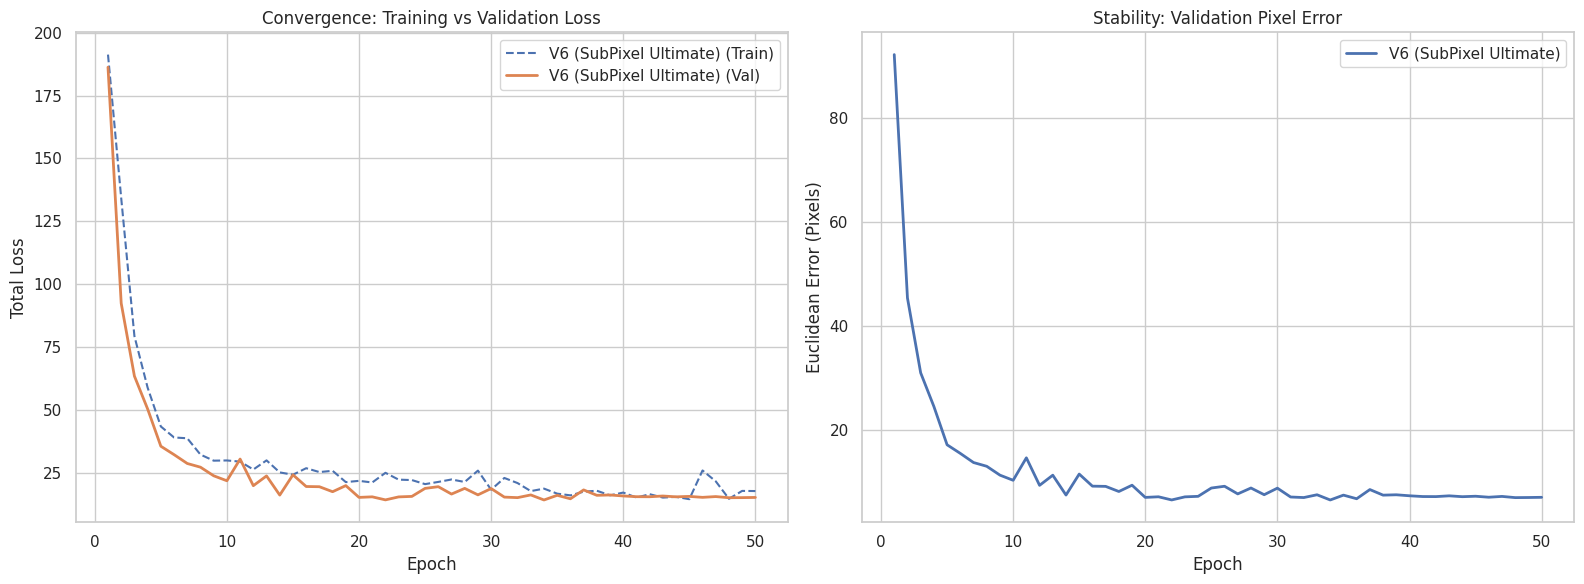

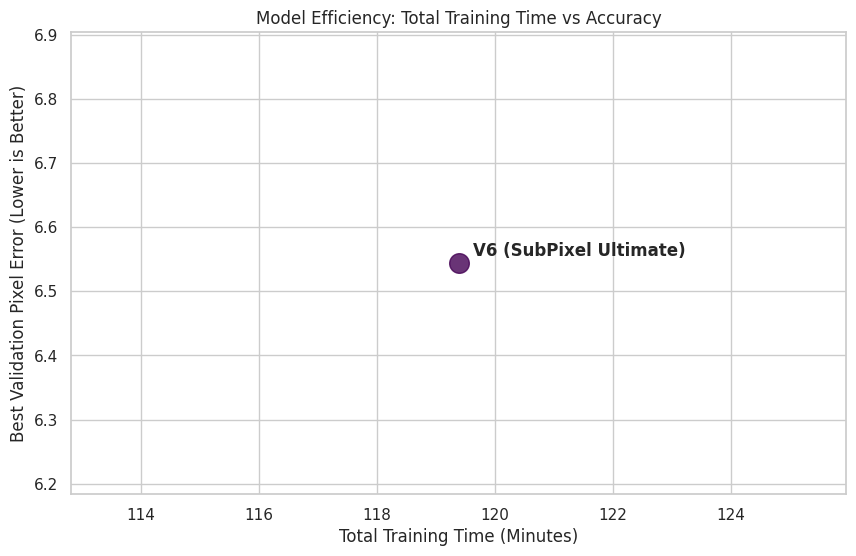

In [17]:
# ============================================
# BLOCK 7: COMPARATIVE ANALYSIS & VISUALIZATION
# ============================================
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np

class KeypointComparativeAnalyzer:
    def __init__(self, result_directories: dict):
        """
        result_directories: dict mapping version names to their directory paths
        e.g., {'V1 (MSE)': './keypoint_rcnn_v1_results', 'V6 (SubPixel)': './keypoint_rcnn_v6_results'}
        """
        self.dirs = {name: Path(path) for name, path in result_directories.items()}
        self.metrics = {}
        self.reports = {}
        self._load_data()
        
        sns.set_theme(style="whitegrid")

    def _load_data(self):
        for name, path in self.dirs.items():
            metrics_file = path / 'training_metrics.csv'
            report_file = path / 'model_comprehensive_report.json'
            
            if metrics_file.exists():
                self.metrics[name] = pd.read_csv(metrics_file)
            if report_file.exists():
                with open(report_file, 'r') as f:
                    self.reports[name] = json.load(f)

    def plot_learning_curves(self):
        """Plots Training and Validation Loss/Metrics across epochs."""
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        for name, df in self.metrics.items():
            axes[0].plot(df['epoch'], df['train_loss'], linestyle='--', label=f'{name} (Train)')
            axes[0].plot(df['epoch'], df['val_loss'], linewidth=2, label=f'{name} (Val)')
            
            if 'val_pixel_err' in df.columns:
                axes[1].plot(df['epoch'], df['val_pixel_err'], linewidth=2, label=name)
        
        axes[0].set_title('Convergence: Training vs Validation Loss')
        axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Total Loss')
        axes[0].legend()
        
        axes[1].set_title('Stability: Validation Pixel Error')
        axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Euclidean Error (Pixels)')
        axes[1].legend()
        
        plt.tight_layout()
        plt.show()

    def generate_comprehensive_table(self):
        """Generates a Parameter vs Metric comparison table."""
        data = []
        for name, report in self.reports.items():
            perf = report['Performance_Artifacts']
            cfg = report['Model_Configuration']
            
            data.append({
                'Version': name,
                'Params (M)': f"{cfg['Architecture']['Total_Parameters'] / 1e6:.1f}M",
                'Resolution': cfg['Architecture'].get('Hidden_Dim', 'Unknown'),
                'Batch Size': cfg['Tuning_Parameters']['Batch_Size'],
                'Best Pixel Error': round(perf.get('Best_Val_Pixel_Error', 0), 2),
                'Time/Epoch (s)': round(perf.get('Average_Time_Per_Epoch_Sec', 0), 1)
            })
            
        df = pd.DataFrame(data).sort_values(by='Best Pixel Error')
        print("\n" + "="*80)
        print("COMPREHENSIVE METRIC & PARAMETER COMPARISON")
        print("="*80)
        display(df)
        return df

    def plot_efficiency_analysis(self):
        """Contrasts Model Training Time against Best Performance."""
        if not self.reports:
            print("No comprehensive reports found for efficiency analysis.")
            return
            
        names = list(self.reports.keys())
        errors = [self.reports[n]['Performance_Artifacts'].get('Best_Val_Pixel_Error', 0) for n in names]
        times = [self.reports[n]['Performance_Artifacts']['Total_Training_Time_Minutes'] for n in names]
        
        plt.figure(figsize=(10, 6))
        scatter = plt.scatter(times, errors, s=200, c=range(len(names)), cmap='viridis', alpha=0.8)
        
        for i, name in enumerate(names):
            plt.annotate(name, (times[i], errors[i]), xytext=(10, 5), textcoords='offset points', fontweight='bold')
            
        plt.title('Model Efficiency: Total Training Time vs Accuracy')
        plt.xlabel('Total Training Time (Minutes)')
        plt.ylabel('Best Validation Pixel Error (Lower is Better)')
        plt.grid(True)
        plt.show()

    def generate_spatial_residuals(self, model, val_loader, device):
        """
        The Keypoint equivalent of a Confusion Matrix. 
        Plots the X and Y coordinate offsets to detect systematic bias.
        Must pass the specific loaded model and val_loader.
        """
        import torch
        model.eval()
        x_errors, y_errors = [], []
        
        with torch.no_grad():
            for images, targets in val_loader:
                images = torch.stack([img.to(device) for img in images])
                predictions = model(images)
                
                # Assuming predictions return 'keypoints' as [N, K, 3] and targets have 'keypoints'
                for i in range(len(targets)):
                    if 'keypoints' not in predictions or len(predictions['keypoints']) == 0:
                        continue
                    
                    # Flatten predictions and match logic to ground truth
                    # (Simplified for visualization: assumes first N preds match N targets)
                    pred_kps = predictions['keypoints'][i][:len(targets[i]['keypoints'])]
                    true_kps = targets[i]['keypoints'].to(device)
                    
                    if len(pred_kps) == len(true_kps):
                        x_err = (pred_kps[:, :, 0] - true_kps[:, :, 0]).cpu().numpy().flatten()
                        y_err = (pred_kps[:, :, 1] - true_kps[:, :, 1]).cpu().numpy().flatten()
                        
                        x_errors.extend(x_err)
                        y_errors.extend(y_err)

        plt.figure(figsize=(8, 8))
        sns.kdeplot(x=x_errors, y=y_errors, cmap="Reds", fill=True, thresh=0.05)
        plt.scatter(x_errors, y_errors, color='black', alpha=0.1, s=10)
        plt.axhline(0, color='blue', linestyle='--', alpha=0.5)
        plt.axvline(0, color='blue', linestyle='--', alpha=0.5)
        
        plt.title('Error Analysis: Spatial Residual Plot')
        plt.xlabel('X-Coordinate Prediction Error (Pixels)')
        plt.ylabel('Y-Coordinate Prediction Error (Pixels)')
        plt.xlim(-10, 10); plt.ylim(-10, 10)
        plt.show()

# ============================================
# EXECUTION (Example Usage)
# ============================================
# Update this dictionary with the actual paths of the versions you ran
directories_to_compare = {
    'V1 (Baseline MSE)': './keypoint_rcnn_v1_results',
    'V5 (Dice + BCE)': './keypoint_rcnn_v5_results',
    'V6 (SubPixel Ultimate)': './keypoint_rcnn_v6_results'
}

analyzer = KeypointComparativeAnalyzer(directories_to_compare)

# 1. Parameter vs Metric & Comprehensive Table
comparison_df = analyzer.generate_comprehensive_table()

# 2. Convergence & Stability
analyzer.plot_learning_curves()

# 3. Model Efficiency
analyzer.plot_efficiency_analysis()

# 4. Error Analysis (Residuals)
# Note: To run the residual plot, you must pass the active model and val_loader.
# analyzer.generate_spatial_residuals(model_v6, val_loader, device)

# *Our 100 epoch model*

In [ ]:
#import shutil
#from IPython.display import FileLink

# Zip the entire /kaggle/working directory
#shutil.make_archive('output_data', 'zip', '/kaggle/working/keypoint_rcnn_v4_results')

# Create a download link for the zipped file
#FileLink(r'output_data.zip')


In [18]:
import torch
import torch.nn.functional as F_nn
import cv2
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ==========================================================
# 1. SETUP & ARCHITECTURE (Ensure your classes match Kaggle)
# ==========================================================
# IMPORTANT: Import or define your DenseSpineKeypointRCNN / RefinedSpineKeypointRCNN here!
# from your_model_file import DenseSpineKeypointRCNN

def load_inference_model(weights_path, device='cpu'):
    print(f"Loading custom model weights from {weights_path}...")
    
    # Initialize the architecture 
    # (Adjust if your final V4 model uses different parameters)
    model = RefinedSpineKeypointRCNN(
        num_keypoints=4, 
        backbone_layers=[2, 2, 2, 2], 
        hidden_dim=256
    )
    
    checkpoint = torch.load(weights_path, map_location=device)
    state_dict = checkpoint.get('model_state_dict', checkpoint)
    new_state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
    
    model.load_state_dict(new_state_dict, strict=False)
    model.to(device)
    model.eval()
    return model

# ==========================================================
# 2. SUB-PIXEL MATH (For Cobb Angle Precision)
# ==========================================================
def get_inference_transform():
    """Forces the rectangular 1024x512 view to prevent vertical compression blindness"""
    return A.Compose([
        A.Resize(1024, 512), 
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ])

def extract_subpixel_peaks(heatmap_tensor, threshold=0.25, min_distance=3):
    """
    Calculates the exact sub-pixel center of mass.
    This guarantees the vectors in Step B of your Cobb Angle math are perfectly straight.
    """
    hm = heatmap_tensor.unsqueeze(0).unsqueeze(0)
    pooled = F_nn.max_pool2d(hm, kernel_size=min_distance*2+1, stride=1, padding=min_distance)
    peaks = (hm == pooled) & (hm > threshold)
    y_coords, x_coords = torch.where(peaks[0, 0])
    
    points = []
    hm_numpy = heatmap_tensor.cpu().numpy()
    
    for y, x in zip(y_coords, x_coords):
        y, x = y.item(), x.item()
        
        y_min, y_max = max(0, y-1), min(hm_numpy.shape[0]-1, y+1)
        x_min, x_max = max(0, x-1), min(hm_numpy.shape[1]-1, x+1)
        patch = hm_numpy[y_min:y_max+1, x_min:x_max+1]
        y_grid, x_grid = np.mgrid[y_min:y_max+1, x_min:x_max+1]
        
        patch_sum = np.sum(patch) + 1e-6
        sub_y = np.sum(y_grid * patch) / patch_sum
        sub_x = np.sum(x_grid * patch) / patch_sum
        
        points.append({'x': sub_x, 'y': sub_y, 'conf': hm_numpy[y, x]})
    return points

# ==========================================================
# 3. SCOLIOVIS API EXPORTER
# ==========================================================
def process_spine_image(image_path, model, device='cpu', threshold=0.25):
    """
    Takes an image, runs the sub-pixel model, and formats the output 
    EXACTLY for the ScolioVis cobb_angle_cal() input requirements.
    """
    # 1. Read Image and get original shape
    image_raw = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image_raw, cv2.COLOR_BGR2RGB)
    
    # image_shape must be (HEIGHT, WIDTH, CHANNELS)
    image_shape = image_rgb.shape 
    orig_h, orig_w = image_shape[0], image_shape[1]
    
    # 2. Preprocess and Predict
    transform = get_inference_transform()
    input_tensor = transform(image=image_rgb)['image'].unsqueeze(0).to(device)
    
    with torch.no_grad():
        with torch.cuda.amp.autocast():
            output = model(input_tensor)
            
    heatmaps = output['keypoint_heatmaps'][0]
    heatmap_h, heatmap_w = heatmaps.shape[1], heatmaps.shape[2]
    
    # 3. Extract Corners and Map back to Original Resolution
    corners = {0: [], 1: [], 2: [], 3: []}
    for k in range(4):
        peaks = extract_subpixel_peaks(heatmaps[k], threshold=threshold)
        for peak in peaks:
            x_scaled = peak['x'] * (orig_w / heatmap_w)
            y_scaled = peak['y'] * (orig_h / heatmap_h)
            corners[k].append({'x': x_scaled, 'y': y_scaled})
            
        # Crucial Step: Sort top-to-bottom so V1 is at index 0
        corners[k].sort(key=lambda pt: pt['y'])
        
    # Cap at 17 complete vertebrae
    num_vertebrae = min(len(corners[0]), len(corners[1]), len(corners[2]), len(corners[3]), 17)
    
    # 4. Construct the `landmark_xy` Flat List
    # Format required: [x1, x2... xn, y1, y2... yn]
    all_x = []
    all_y = []
    
    for i in range(num_vertebrae):
        # Grab the 4 corners for this specific vertebra (TL, TR, BL, BR)
        tl, tr, bl, br = corners[0][i], corners[1][i], corners[2][i], corners[3][i]
        
        # Append X coordinates
        all_x.extend([tl['x'], tr['x'], bl['x'], br['x']])
        # Append Y coordinates
        all_y.extend([tl['y'], tr['y'], bl['y'], br['y']])
        
    landmark_xy = all_x + all_y
    
    return landmark_xy, image_shape

# ==========================================================
# 4. USAGE EXAMPLE FOR YOUR APP
# ==========================================================
if __name__ == "__main__":
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    MODEL_WEIGHTS = "/kaggle/working/keypoint_rcnn_v6_results/best_model.pth"
    TEST_IMAGE = "/kaggle/input/datasets/ruturajkasture07/testing3/016026.jpg"
    
    # Initialize the model once when your app starts
    spine_model = load_inference_model(MODEL_WEIGHTS, DEVICE)
    
    # Run this every time a new image is uploaded
    landmark_xy, image_shape = process_spine_image(TEST_IMAGE, spine_model, DEVICE)
    
    print(f"Extracted {int(len(landmark_xy)/8)} vertebrae.")
    print(f"image_shape output: {image_shape}")
    print(f"landmark_xy output (first 10 values): {landmark_xy[:10]}...")
    
    # ---------------------------------------------------------
    # PASS TO SCOLIOVIS:
    # cobb_angles_list, angles_with_pos, curve_type, midpoint_lines = cobb_angle_cal(landmark_xy, image_shape)
    # ---------------------------------------------------------

Loading custom model weights from /kaggle/working/keypoint_rcnn_v6_results/best_model.pth...


RuntimeError: Error(s) in loading state_dict for RefinedSpineKeypointRCNN:
	size mismatch for rpn.cls_logits.weight: copying a param with shape torch.Size([15, 256, 1, 1]) from checkpoint, the shape in current model is torch.Size([9, 256, 1, 1]).
	size mismatch for rpn.cls_logits.bias: copying a param with shape torch.Size([15]) from checkpoint, the shape in current model is torch.Size([9]).
	size mismatch for rpn.bbox_pred.weight: copying a param with shape torch.Size([60, 256, 1, 1]) from checkpoint, the shape in current model is torch.Size([36, 256, 1, 1]).
	size mismatch for rpn.bbox_pred.bias: copying a param with shape torch.Size([60]) from checkpoint, the shape in current model is torch.Size([36]).

# *Model 2*

In [ ]:
import torch
import torchvision
from torchvision.transforms import functional as F
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torchvision.models.detection.rpn import AnchorGenerator

# ==========================================================
# 1. SETUP & MODEL LOADING
# ==========================================================
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

def get_kprcnn_model(num_keypoints=4, weights_path=None):
    """Loads the standard PyTorch Keypoint R-CNN architecture"""
    print("Initializing architecture...")
    anchor_generator = AnchorGenerator(sizes=(32, 64, 128, 256, 512), aspect_ratios=(0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0))
    model = torchvision.models.detection.keypointrcnn_resnet50_fpn(
        pretrained=False,
        pretrained_backbone=False,
        num_keypoints=num_keypoints,
        num_classes=2,
        rpn_anchor_generator=anchor_generator
    )

    if weights_path:
        print(f"Loading weights from {weights_path}...")
        state_dict = torch.load(weights_path, map_location=device)
        
        # Handle different saved dictionary structures
        if 'model_state_dict' in state_dict:
            state_dict = state_dict['model_state_dict']
            
        # Strip DataParallel 'module.' prefix if it exists
        new_state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
        model.load_state_dict(new_state_dict, strict=False)        
        
    return model

# Initialize Global Model
# ---> POINT THIS TO YOUR .PTH FILE <---
WEIGHTS_PATH = "/kaggle/input/models/ruturajkasture/original-kp/pytorch/default/1/keypointsrcnn_weights.pt"
model = get_kprcnn_model(num_keypoints=4, weights_path=WEIGHTS_PATH)
model.to(device)
model.eval()

# ==========================================================
# 2. INTERNAL FILTERING LOGIC (NMS & Sorting)
# ==========================================================
def extract_and_format_cobb_landmarks(output, score_threshold=0.5, nms_threshold=0.3, max_vertebrae=17):
    """
    Filters Keypoint R-CNN output and formats it strictly for cobb_angle_cal()
    Target Output: Flat list [x1, x2... xn, y1, y2... yn]
    """
    # 1. Filter by Confidence & Apply NMS
    scores = output['scores'].detach().cpu().numpy()
    high_scores_idxs = np.where(scores > score_threshold)[0].tolist()

    if not high_scores_idxs:
        return [] # No vertebrae found

    post_nms_idxs = torchvision.ops.nms(
        output['boxes'][high_scores_idxs],
        output['scores'][high_scores_idxs],
        nms_threshold
    ).cpu().numpy()

    np_keypoints = output['keypoints'][high_scores_idxs][post_nms_idxs].detach().cpu().numpy()
    np_bboxes = output['boxes'][high_scores_idxs][post_nms_idxs].detach().cpu().numpy()
    np_scores = output['scores'][high_scores_idxs][post_nms_idxs].detach().cpu().numpy()

    # Limit to top scoring (e.g., 17 vertebrae maximum)
    sorted_scores_idxs = np.argsort(-1 * np_scores)
    np_keypoints = np_keypoints[sorted_scores_idxs][:max_vertebrae]
    np_bboxes = np_bboxes[sorted_scores_idxs][:max_vertebrae]

    # 2. ANATOMICAL SORTING (Top to Bottom)
    # Sort by the Y-coordinate of the bounding box centers for maximum stability
    centers_y = (np_bboxes[:, 1] + np_bboxes[:, 3]) / 2.0
    anatomical_idxs = np.argsort(centers_y)
    sorted_keypoints = np_keypoints[anatomical_idxs] # Shape: [num_vert, 4, 3]

    # 3. GEOMETRIC CORNER ENFORCEMENT
    # Prevents model from swapping TL/TR or BL/BR, which would ruin your midpoint math
    ordered_xy_keypoints = []
    
    for kps in sorted_keypoints:
        pts = kps[:, :2] # Extract only X, Y (drop visibility)
        
        # Sort by Y first to separate the Top pair from the Bottom pair
        y_sorted = pts[np.argsort(pts[:, 1])]
        top_pair = y_sorted[:2]
        bottom_pair = y_sorted[2:]

        # Sort Top pair by X (Left then Right) -> KP1, KP2
        top_pair = top_pair[np.argsort(top_pair[:, 0])]
        tl, tr = top_pair[0], top_pair[1]

        # Sort Bottom pair by X (Left then Right) -> KP3, KP4
        bottom_pair = bottom_pair[np.argsort(bottom_pair[:, 0])]
        bl, br = bottom_pair[0], bottom_pair[1]

        # Append in strict order: [TL, TR, BL, BR]
        ordered_xy_keypoints.extend([tl, tr, bl, br])

    # Convert to numpy array for easy slicing
    ordered_xy_keypoints = np.array(ordered_xy_keypoints) # Shape: [n, 2]

    # 4. FINAL FLATTENING [x1...xn, y1...yn]
    x_coords = ordered_xy_keypoints[:, 0].tolist()
    y_coords = ordered_xy_keypoints[:, 1].tolist()

    landmark_xy = x_coords + y_coords

    return landmark_xy

# ==========================================================
# 3. PREDICT INTERFACE
# ==========================================================
def predict(images):
    images_input = []
    if type(images) == str:
        img = cv2.cvtColor(cv2.imread(images), cv2.COLOR_BGR2RGB)
        images_input.append(F.to_tensor(img))
    
    images_input = [image.to(device) for image in images_input]

    with torch.no_grad():
        outputs = model(images_input) 

    filtered_outputs = [_filter_output(output) for output in outputs]
    return filtered_outputs

# ==========================================================
# 4. VISUALIZATION TEST
# ==========================================================
def test_and_visualize(image_path):
    print(f"\nProcessing image: {image_path}")
    results = predict(image_path)
    
    if not results or len(results[0][0]) == 0:
        print("No vertebrae detected! Check your weights or threshold.")
        return
        
    bboxes, keypoints, scores = results[0]
    num_vertebrae = len(bboxes)
    
    print("\n" + "="*40)
    print(f"SUCCESS! Found {num_vertebrae} Vertebrae")
    print("="*40)
    
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(10, 20)) 
    plt.imshow(img)
    ax = plt.gca()
    
    colors = ['red', 'blue', 'lime', 'magenta'] 
    
    for i in range(num_vertebrae):
        xmin, ymin, xmax, ymax = bboxes[i]
        
        # Draw Box
        rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, 
                                 linewidth=2, edgecolor='cyan', facecolor='none')
        ax.add_patch(rect)
        
        # Draw Points
        for j, kp in enumerate(keypoints[i]):
            plt.scatter(kp[0], kp[1], c=colors[j], s=40, edgecolors='white', zorder=5)
        
        # Draw Label
        plt.text(xmin - 50, ymin, f"V{i+1}\n({scores[i]:.2f})", color='cyan', 
                 fontsize=10, fontweight='bold', bbox=dict(facecolor='black', alpha=0.5))
                 
    plt.axis('off')
    plt.title(f"API Output Verification: {num_vertebrae} Vertebrae", fontsize=16)
    plt.tight_layout()
    plt.show()

# ==========================================================
# 5. RUN THE SCRIPT
# ==========================================================
if __name__ == "__main__":
    # ---> POINT THIS TO YOUR TEST IMAGE <---
    TEST_IMAGE = "/kaggle/input/datasets/ruturajkasture/testing1/sunhl-1th-10-Jan-2017-235 D AP.jpg" 
    test_and_visualize(TEST_IMAGE)